In [ ]:
import pandas as pd
import numpy as np
import glob, os



In [ ]:
path = r'/Users/jamiewood/Documents/DATA3888/DATA3888G08/individual_book_train'
files = glob.glob(os.path.join(path, "*.csv"))
print(files)


In [ ]:
def aggregate_stock(f):
    df = pd.read_csv(f)

    # Compute WAP and BidAskSpread
    df['WAP'] = (df['bid_price1'] * df['ask_size1'] + df['ask_price1'] * df['bid_size1']) / \
                (df['bid_size1'] + df['ask_size1'])
    df['BidAskSpread'] = df['ask_price1'] / df['bid_price1'] - 1

    # Compute log return within each time_id
    df = df.sort_values(['time_id', 'seconds_in_bucket'])
    df['log_return'] = df.groupby('time_id')['WAP'].transform(
        lambda x: np.log(x / x.shift(1))
    ).fillna(0)

    # Assign 30s bucket
    df['time_bucket'] = np.ceil(df['seconds_in_bucket'] / 30).astype(int)

    # Aggregate per time_id + 30s bucket
    agg = df.groupby(['stock_id', 'time_id', 'time_bucket']).agg(
        WAP_mean      = ('WAP', 'mean'),
        BidAskSpread_mean = ('BidAskSpread', 'mean'),
        volatility    = ('log_return', lambda x: np.sqrt(np.sum(x**2)))
    ).reset_index()

    return agg  # ~10,000 rows instead of ~1,500,000

# Process one file at a time, never loading all raw data at once
all_stocks = pd.concat([aggregate_stock(f) for f in files], ignore_index=True)

print(all_stocks.shape)
print(f"Memory: {all_stocks.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Save the merged aggregated file — tiny!
output_path = r'/Users/jamiewood/Documents/DATA3888/DATA3888G08/optiver_aggregated.csv'

all_stocks.to_csv(output_path, index=False)

print("Done!")

In [ ]:
''' 
These line of code will be commented out since I already merged all file. 
Basically, 126 csv files has been aggregated as week 3's material instruction indicated, the new merged file will contain stock information, WAP, BAS, and
log return.
'''
# import duckdb

# path = r'd:\USYD\DATA3888\group_asm\Optiver\individual_book_train'

# conn = duckdb.connect()

# result = conn.execute(f"""
#     SELECT
#         stock_id,
#         time_id,
#         CEIL(seconds_in_bucket / 30.0) AS time_bucket,
#         AVG((bid_price1 * ask_size1 + ask_price1 * bid_size1) / 
#             (bid_size1 + ask_size1)) AS WAP_mean,
#         AVG(ask_price1 / bid_price1 - 1) AS BidAskSpread_mean,
#         SQRT(SUM(POWER(
#             LN((bid_price1 * ask_size1 + ask_price1 * bid_size1) / 
#                (bid_size1 + ask_size1)), 2)
#         )) AS volatility
#     FROM read_csv_auto('{path}/*.csv')
#     GROUP BY stock_id, time_id, time_bucket
#     ORDER BY stock_id, time_id, time_bucket
# """).df()  # returns a pandas dataframe

# result.to_csv(r'd:\USYD\DATA3888\group_asm\optiver_aggregated.csv', index=False)
# print(result.shape)

In [ ]:
size_mb = os.path.getsize(output_path) / (1024**2)
print(f"File size: {size_mb:.2f} MB")

# Reload and check RAM usage
df = pd.read_csv(output_path)

mem_mb = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Shape: {df.shape}")
print(f"RAM usage: {mem_mb:.2f} MB")
print(df.head())

Only do stock_id=1 
Illiquid & Liquid: 10 each --> 20 total

Added liquidity regime classification (liquid vs illiquid per stock, not just per time period), plus EDA that supports the team's cross-model comparison pipeline

Bucket-level classification — every (stock_id, time_id, time_bucket) row gets a bucket_liquidity label (liquid, mixed, illiquid) based on whether BAS is tight and activity is high simultaneously, using training-set quantiles as thresholds.
Stock-level profile — aggregates those labels per stock_id to produce a stock_regime and a recommended_model column (EGARCH-X for liquid, WLS / HAR-RV for illiquid/mixed). This feeds directly into the app's dynamic model recommendation logic.

EDA Plot — liquidity_regime_eda.png
A 7-panel figure showing the BAS vs activity scatter with regime boundaries, how RV and BAS distributions differ by regime, and a per-stock scatter plot (each dot = one stock, coloured by regime). This is Jamie's primary EDA deliverable per the feedback.

Per-Stock Evaluation
Runs WLS metrics (QLIKE, MSE, MAE) grouped by stock_id rather than just by time bucket. Prints a stability comparison across liquid/illiquid stock groups to demonstrate WLS doesn't blow up where EGARCH-X does.

FilePurposem2_wls_predictions.csvSame as before + bucket_liquidity, stock_regime, recommended_model columns for Jisu to cross-reference with GARCH failuresm2_stock_liquidity_profile.csvPer-stock median_bas, liquid_pct, illiquid_pct, recommended_model — for the app's Liquidity Profile displaym2_per_stock_eval.csvPer-stock WLS QLIKE/MSE/MAE — for the team's cross-model comparison pipeline

Liquidity Regime Classification
This is the largest and most important addition. It has two distinct layers.
4A — Bucket-level classification
pythonbas_q33   = train["bas"].quantile(0.33)
bas_q66   = train["bas"].quantile(0.66)
act_q33   = train["log_activity"].quantile(0.33)
act_q66   = train["log_activity"].quantile(0.66)
These four numbers become the classification boundaries. They're computed on the training set only — the test set never touches them — which prevents data leakage. log_activity is the order-flow proxy derived earlier as log(WAP × inv_spread), where inv_spread = 1 / (BAS + ε). A tight spread means high inverse spread, which means high activity — so the two signals are correlated but not identical.
pythondef bucket_liquidity_label(bas_val, act_val, bas_lo, bas_hi, act_lo, act_hi):
    spread_tight  = bas_val <= bas_lo
    spread_wide   = bas_val >= bas_hi
    activity_high = act_val >= act_hi
    activity_low  = act_val <= act_lo

    if spread_tight and activity_high:
        return "liquid"
    elif spread_wide and activity_low:
        return "illiquid"
    else:
        return "mixed"
The classification requires both conditions to be met simultaneously. A row is only liquid if the spread is in the bottom third AND activity is in the top third at the same time. A row is only illiquid if the spread is in the top third AND activity is in the bottom third. Everything in between is mixed. This joint condition matters — a stock can have a temporarily wide spread for structural reasons while still being actively traded, and you don't want to mislabel that as illiquid.
pythonfor frame in [train, test]:
    frame["bucket_liquidity"] = frame.apply(
        lambda r: bucket_liquidity_label(...), axis=1
    )
The same thresholds from the training set are applied to both frames, so the test set labels are comparable.
4B — Stock-level profile
pythonstock_liquidity = (
    train.groupby("stock_id")
    .agg(
        median_bas          = ("bas",              "median"),
        median_log_activity = ("log_activity",     "median"),
        liquid_pct          = ("bucket_liquidity", lambda x: (x == "liquid").mean()),
        illiquid_pct        = ("bucket_liquidity", lambda x: (x == "illiquid").mean()),
        ...
    )
)
This collapses the entire training history of each stock into a single summary row. median_bas and median_log_activity describe the stock's typical market conditions. liquid_pct and illiquid_pct describe what fraction of its 30-second buckets fell into each regime. The median is used instead of the mean for BAS because spread distributions are right-skewed — a few extremely wide-spread moments would inflate the mean and misrepresent the stock's normal state.
pythondef stock_regime(row):
    if row["liquid_pct"] >= 0.40:
        return "liquid"
    elif row["illiquid_pct"] >= 0.40:
        return "illiquid"
    else:
        return "mixed"
The 40% threshold means a stock needs to spend at least 40% of its time in a regime before being labelled that way. This avoids over-classifying stocks that are occasionally liquid or illiquid but mostly sit in the middle.
pythondef recommended_model(regime):
    if regime == "liquid":
        return "EGARCH-X"
    elif regime == "illiquid":
        return "WLS / HAR-RV"
    else:
        return "WLS / HAR-RV"
Both illiquid and mixed stocks are routed to WLS/HAR-RV. This is the conservative choice — when in doubt, use the numerically stable model. The app uses this column directly to display its recommendation without needing to re-run any model logic.

New EDA Plot — liquidity_regime_eda.png
This is a 7-panel figure built with GridSpec. The panels worth explaining in detail:
Panel A — BAS vs log_activity scatter:
pythonfor regime, color in LIQ_COLORS.items():
    sub = eda_sample[eda_sample["bucket_liquidity"] == regime]
    ax_scatter.scatter(sub["bas"], sub["log_activity"], ...)
ax_scatter.axvline(bas_q33, ...)
ax_scatter.axvline(bas_q66, ...)
ax_scatter.axhline(act_q33, ...)
ax_scatter.axhline(act_q66, ...)
This plots every sampled bucket as a point in BAS-activity space, coloured by its assigned regime. The four threshold lines divide the space into a 3×3 grid. The bottom-right corner (low BAS, high activity) should be mostly teal/liquid. The top-left corner (high BAS, low activity) should be mostly red/illiquid. Showing this visually validates that the classification logic is capturing a real structure in the data rather than arbitrarily slicing.
Panel F — Per-stock scatter:
pythonfor regime, color in STOCK_COLORS.items():
    sub = stock_liquidity[stock_liquidity["stock_regime"] == regime]
    ax_stock.scatter(sub["median_bas"], sub["median_log_activity"], ...)
Each dot here is one stock, not one bucket. This answers the feedback question directly — you can see visually which specific stocks are illiquid. The annotation loop labels the most illiquid stocks by their stock_id so they can be looked up and cross-referenced with GARCH's failure list.

Section 14 — Per-Stock Evaluation
pythontest_eval = test_eval.merge(
    test[["stock_id", "time_id", "time_bucket", "bucket_liquidity"]],
    on=["stock_id", "time_id", "time_bucket"], how="left"
)
test_eval = test_eval.merge(
    stock_liquidity[["stock_id", "stock_regime", "recommended_model", ...]],
    on="stock_id", how="left"
)
These two merges attach the liquidity labels back onto the prediction rows. The first merge brings in the bucket-level label (since test_eval was built from test_clean which dropped NaNs, the merge is needed to reattach that column). The second brings in the stock-level profile. After this, every prediction row knows both its bucket's liquidity state and its stock's overall regime.
pythondef stock_metrics(grp):
    y    = grp[TARGET].values
    yhat = grp["wls_pred"].values
    return pd.Series({
        "wls_qlike":  qlike(y, yhat),
        "wls_mse":    mse(y, yhat),
        "ols_qlike":  qlike(y, grp["ols_pred"].values),
        "stock_regime": grp["stock_regime"].iloc[0],
        ...
    })

per_stock_eval = test_eval.groupby("stock_id").apply(stock_metrics)
This computes all three loss metrics independently for each stock. Importantly, it also carries through ols_qlike so the WLS vs OLS comparison can be made at the stock level, not just in aggregate. The .iloc[0] on stock_regime just picks the regime label — it's the same value for every row of that stock so any row would work.
pythonprint("\n  WLS performance by stock liquidity regime:")
for regime in ["liquid", "mixed", "illiquid"]:
    sub = per_stock_eval[per_stock_eval["stock_regime"] == regime]
    print(f"  {regime}: median QLIKE={sub['wls_qlike'].median():.6f}")
This is the key diagnostic for Rosa — it shows whether WLS QLIKE is stable across regimes. If illiquid stocks have similar QLIKE to liquid ones, that's the proof that WLS doesn't suffer from the same divergence problem as EGARCH-X.
The per-stock plot has two panels: a bar chart of QLIKE sorted by performance (coloured by regime, so you can see visually if red/illiquid bars cluster at the bad end), and a scatter of OLS QLIKE vs WLS QLIKE per stock. Points below the diagonal mean WLS beat OLS for that stock. Points above mean OLS was better. The regime colouring lets you see if WLS's advantage is concentrated in a particular liquidity segment.

Updated Output CSVs
m2_wls_predictions.csv gains three new columns:

bucket_liquidity — the regime of that specific 30-second window
stock_regime — the overall regime of that stock
recommended_model — which model the app should highlight

Jisu's workflow is: load their GARCH predictions, merge on (stock_id, time_id, time_bucket), and wherever GARCH blew up they can immediately see whether the stock_regime column says illiquid. If the blow-ups cluster on illiquid stocks, that confirms the team's hypothesis.
m2_stock_liquidity_profile.csv is the app's lookup table. When a user inputs a stock ticker, the app queries this file for that stock_id and reads off recommended_model, liquid_pct, illiquid_pct, median_bas, and median_log_activity to populate the Liquidity Profile panel without any on-the-fly computation.
m2_per_stock_eval.csv is the cross-model comparison table. It has one row per stock with WLS's QLIKE, MSE, and MAE. When Jisu exports their equivalent GARCH per-stock metrics, the two CSVs can be joined on stock_id to produce a side-by-side comparison showing exactly which model wins on each stock and whether that result is explained by the stock's liquidity regime.

LOADING FULL DATASET
  Full dataset (bucket-0 dropped): (8569731, 6)
  Unique stocks: 112

██████████████████████████████████████████████████████████████████████
PHASE 1 — WLS BASELINE  (stock_id = 1)  +  DATA-DRIVEN FEATURE SELECTION
██████████████████████████████████████████████████████████████████████
  stock_id=1 rows: 76,590
  Train buckets: 1–16  |  Val buckets: 17–20
  Train rows: 61,274   Val rows: 15,316
  Engineering features …

  Running data-driven feature selection on stock_id=1 training data …

  [FEATURE SELECTION] Candidate pool : 32 features
  [FEATURE SELECTION] Dropped (|r| < 0.05): ['spread_change_vol', 'wap', 'wap_accel', 'wap_dev', 'wap_return', 'wap_return2']
  [FEATURE SELECTION] Dropped (collinear > 0.95): ['activity_vol', 'bas_lag1', 'rel_spread', 'rv_roll_max', 'spread_imbalance', 'spread_vol_interaction']
  [FEATURE SELECTION] Final features (20): ['rv_roll_mean', 'bas', 'rv_lag1', 'bas_roll_mean', 'rv_lag2', 'rel_spread_lag1', 'log_activity', 'rv_lag3', 'rv

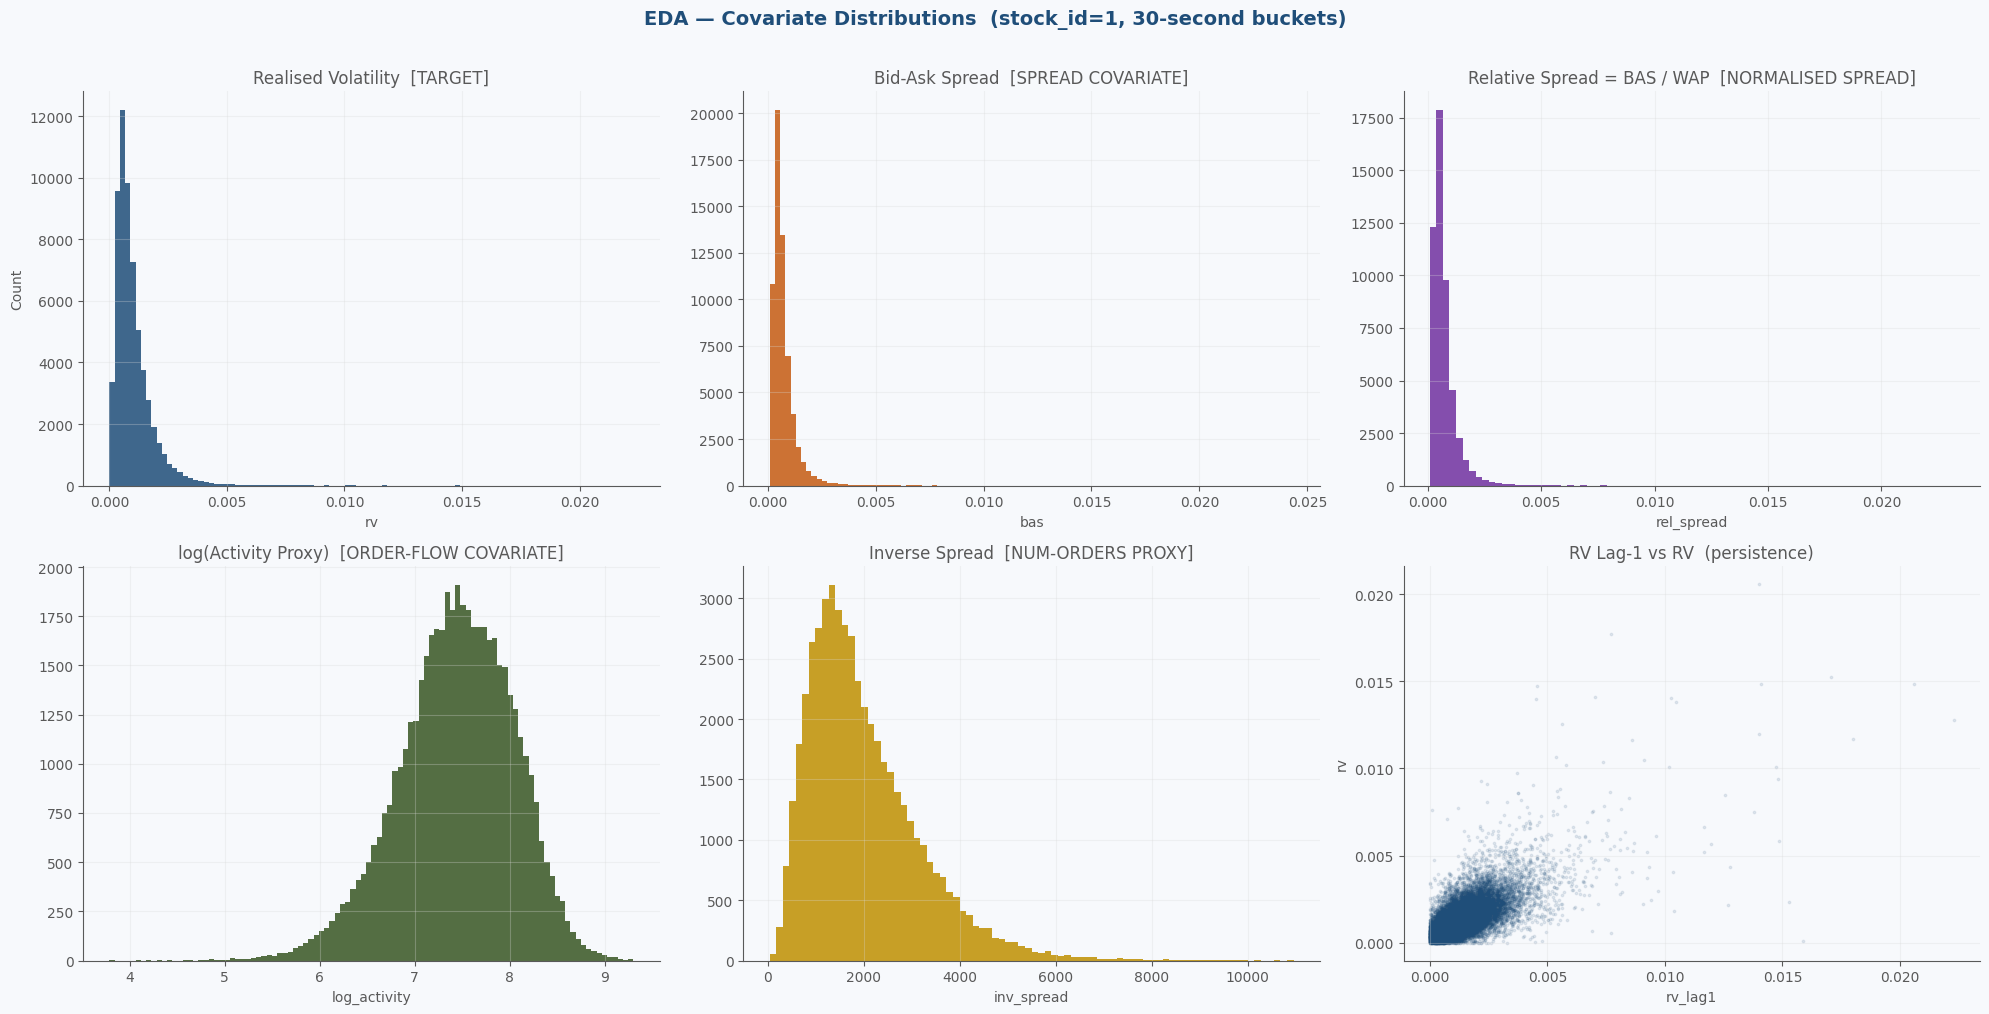

  Saved: eda_distributions.png  ✓


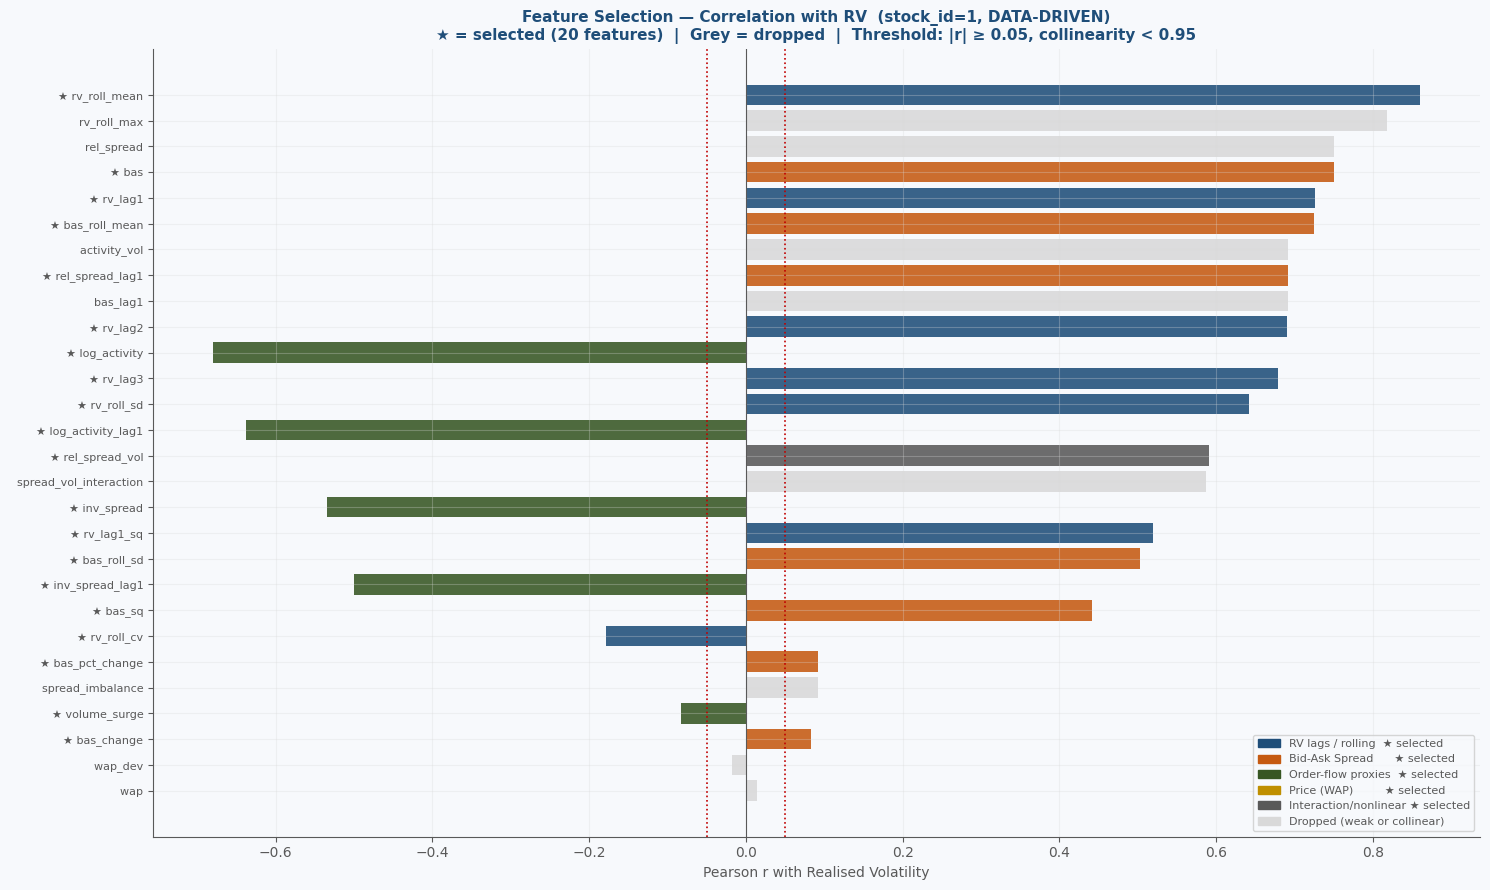

  Saved: feature_selection_correlation.png  ✓


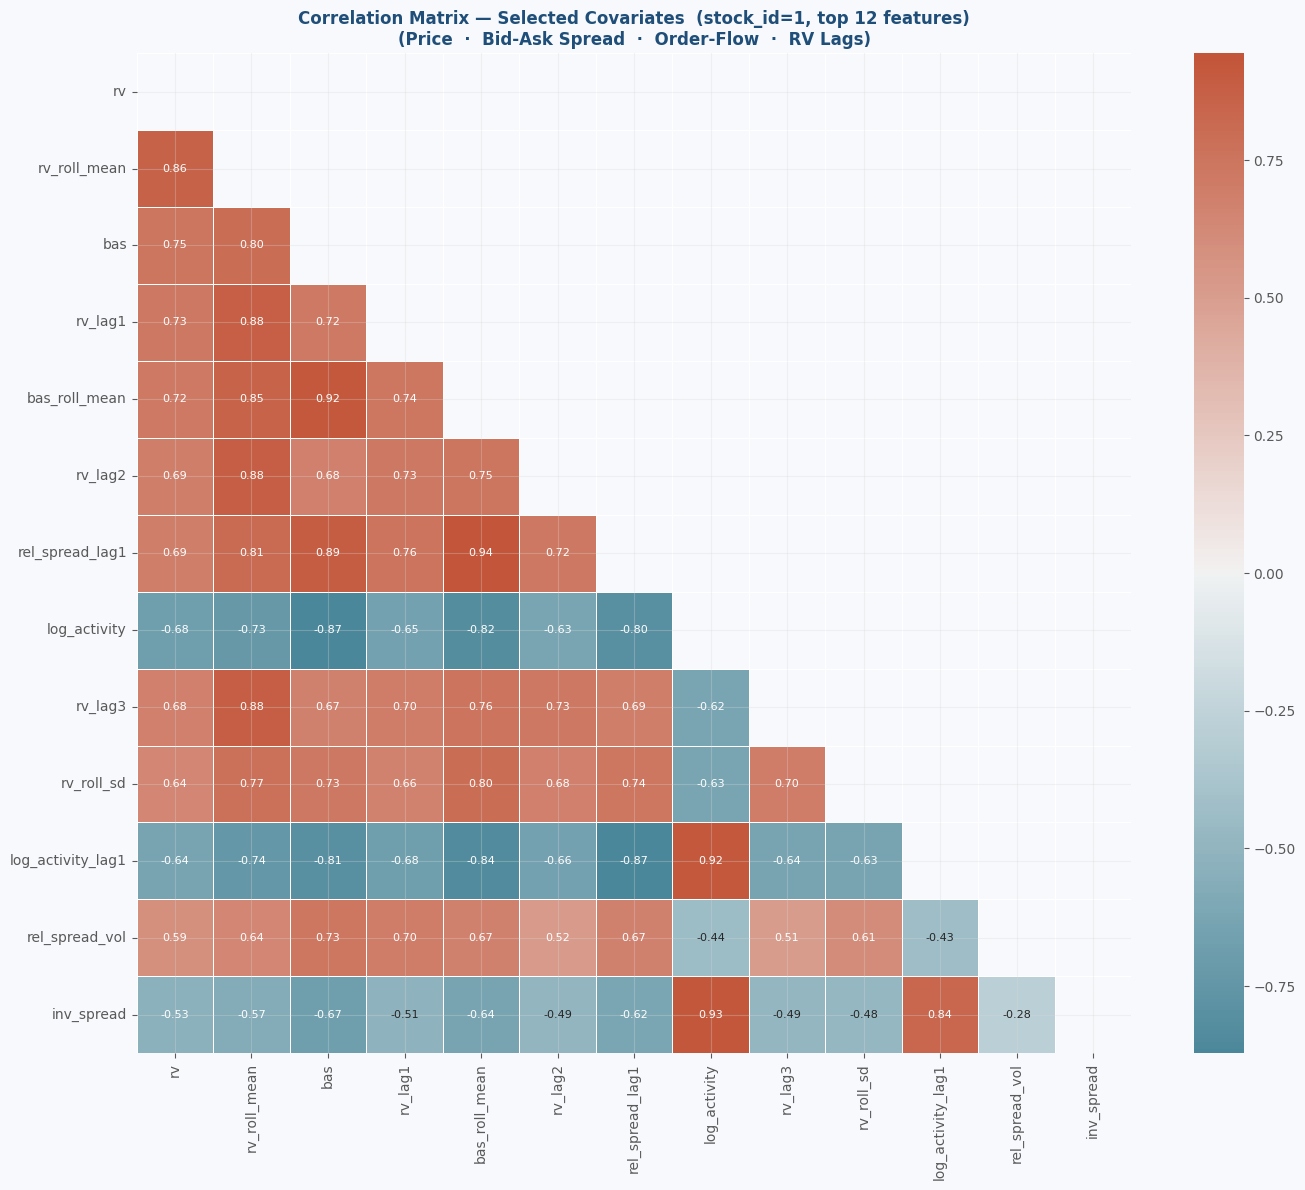

  Saved: correlation_heatmap.png  ✓


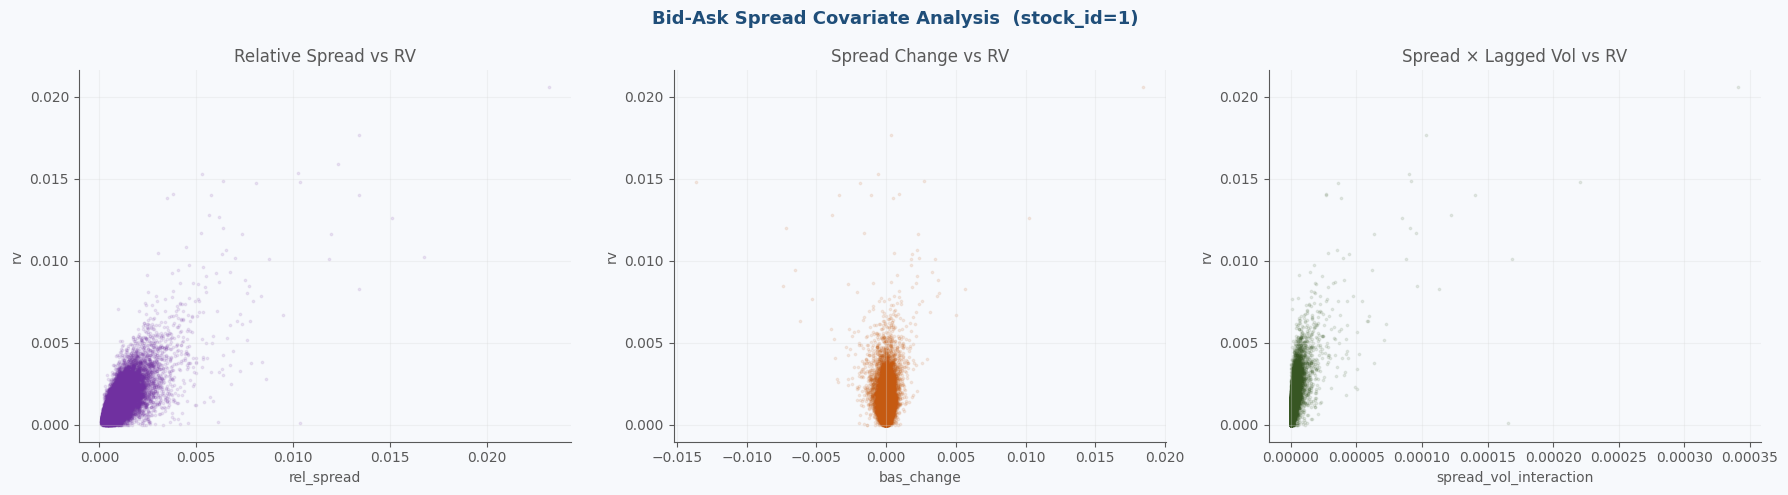

  Saved: spread_features_eda.png  ✓


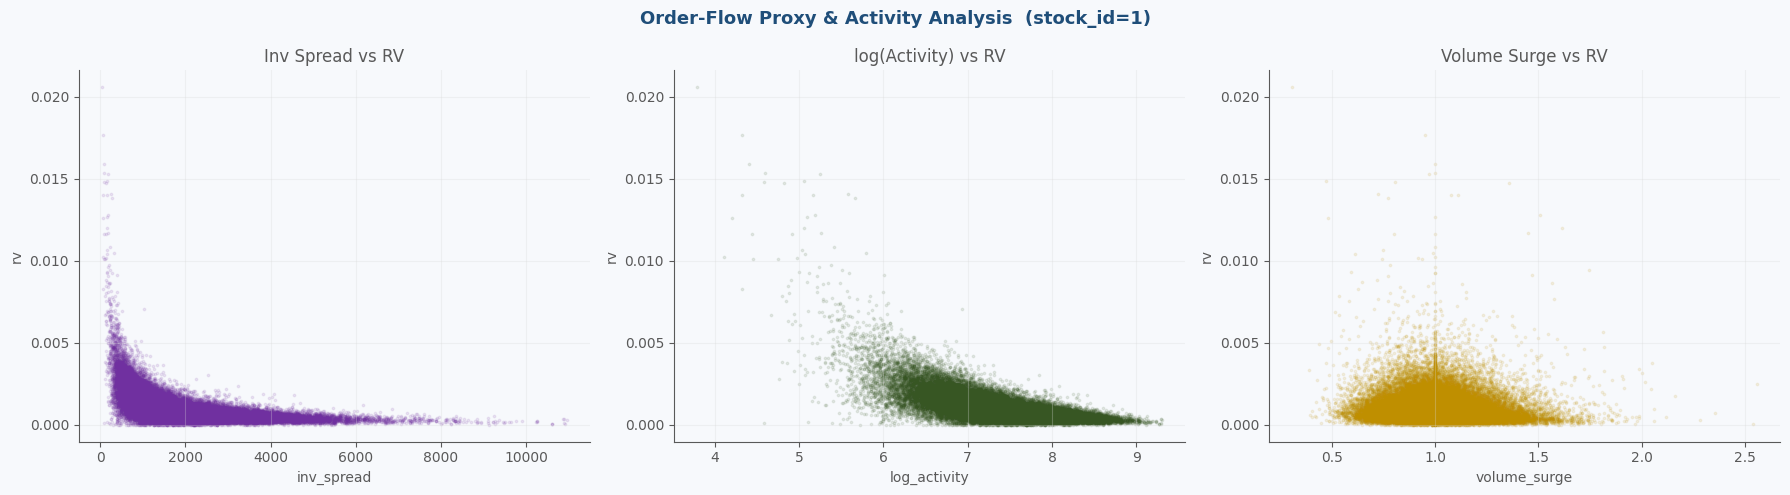

  Saved: order_flow_features_eda.png  ✓


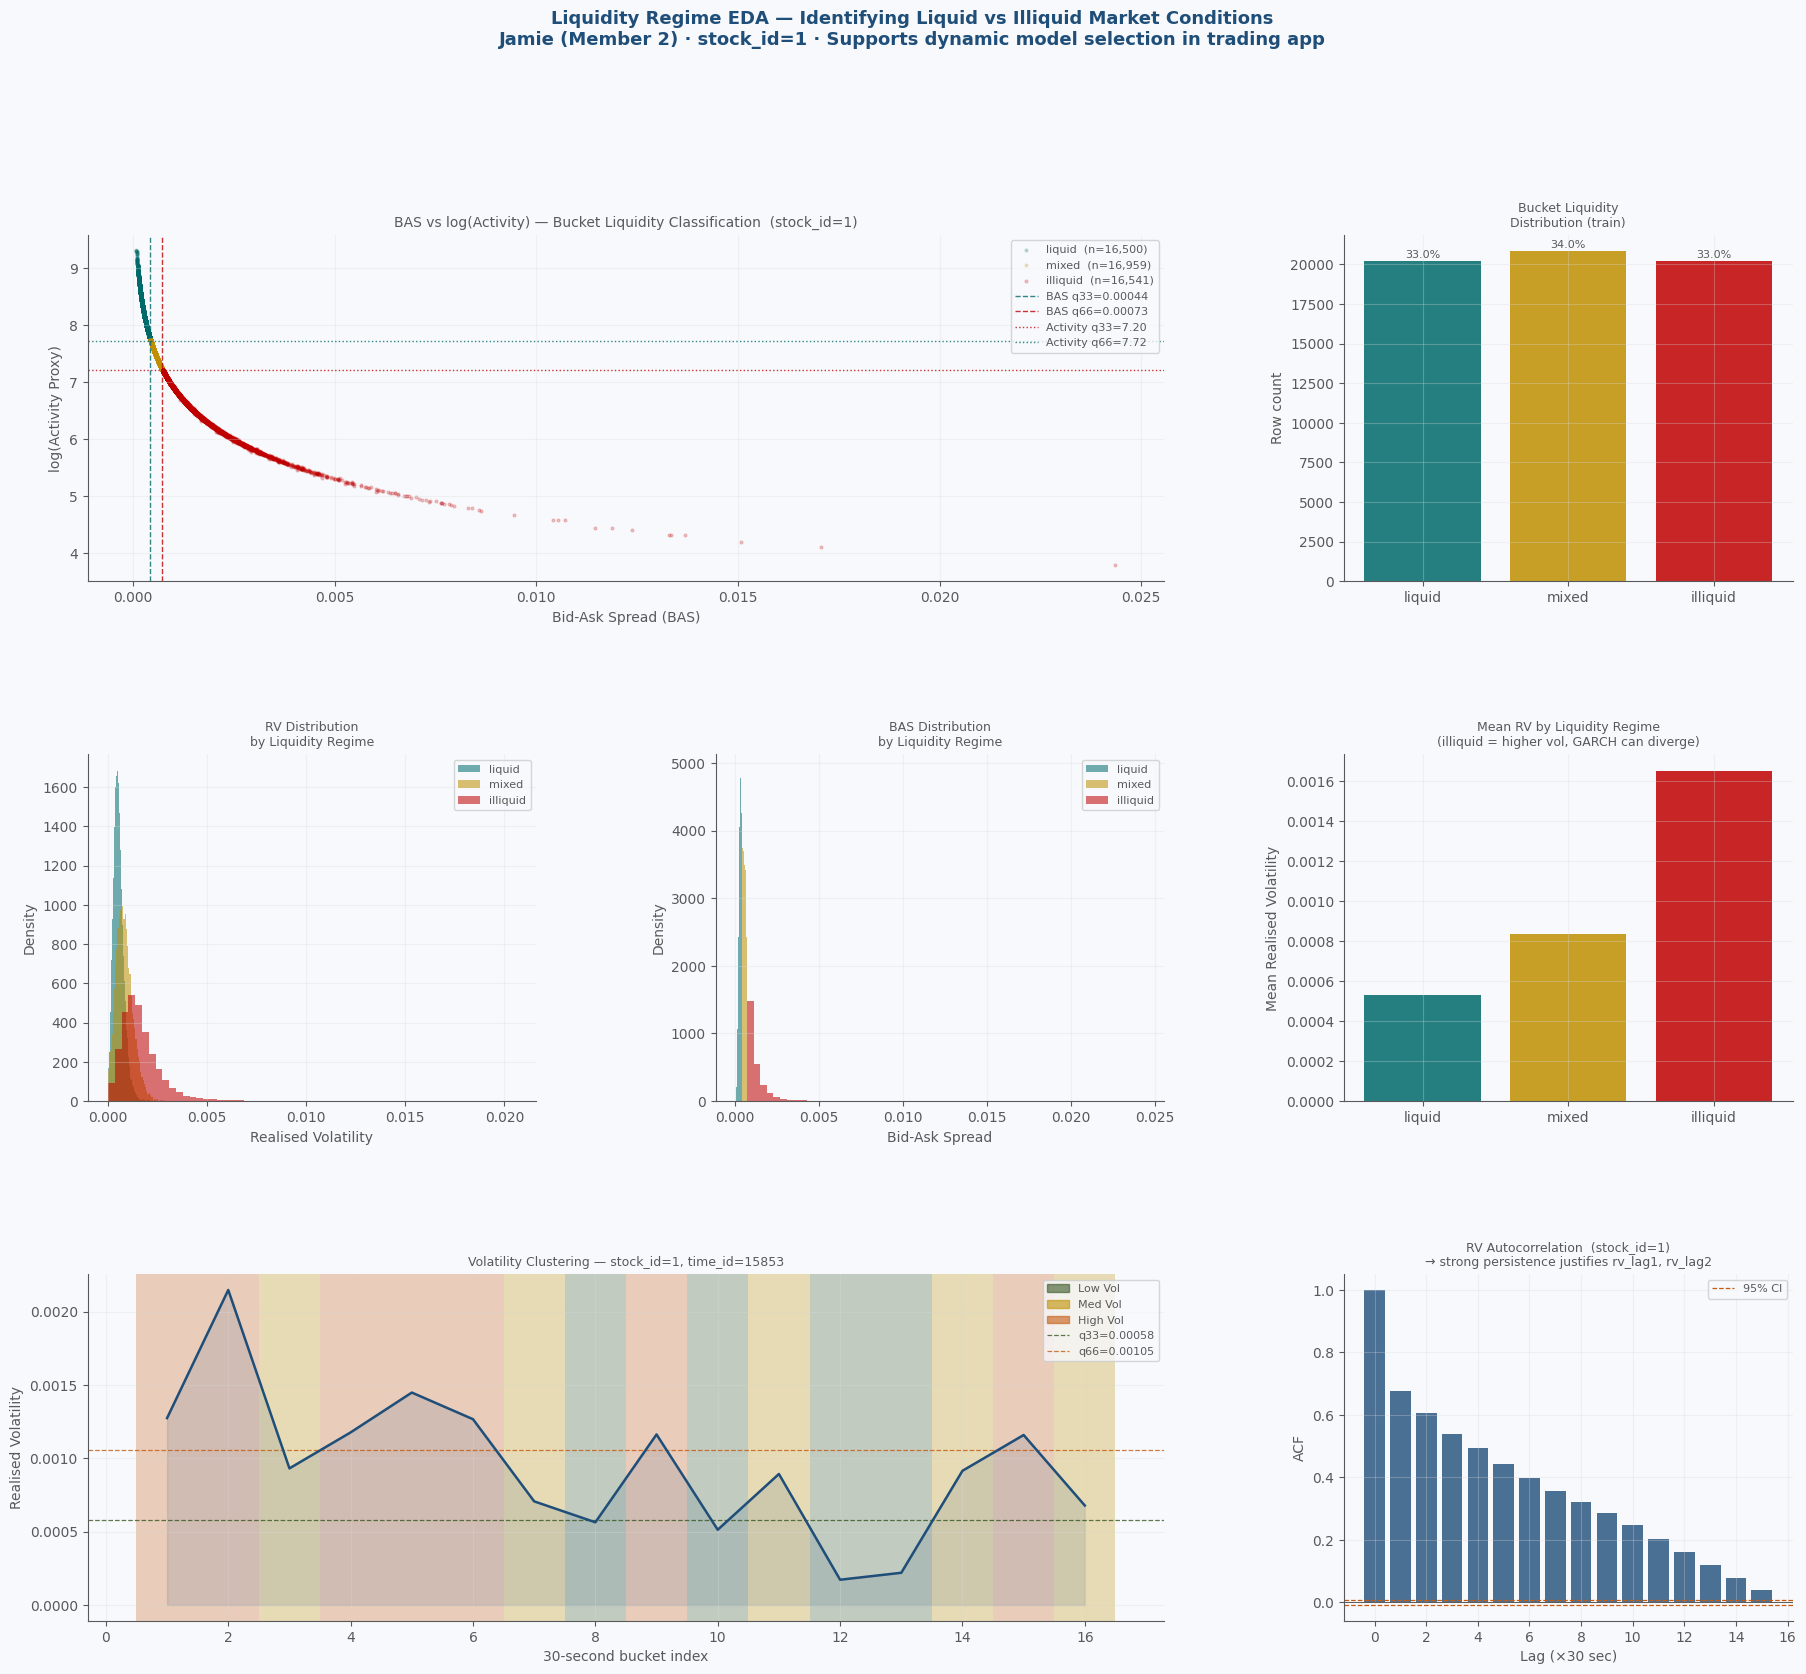

  Saved: liquidity_regime_eda.png  ✓


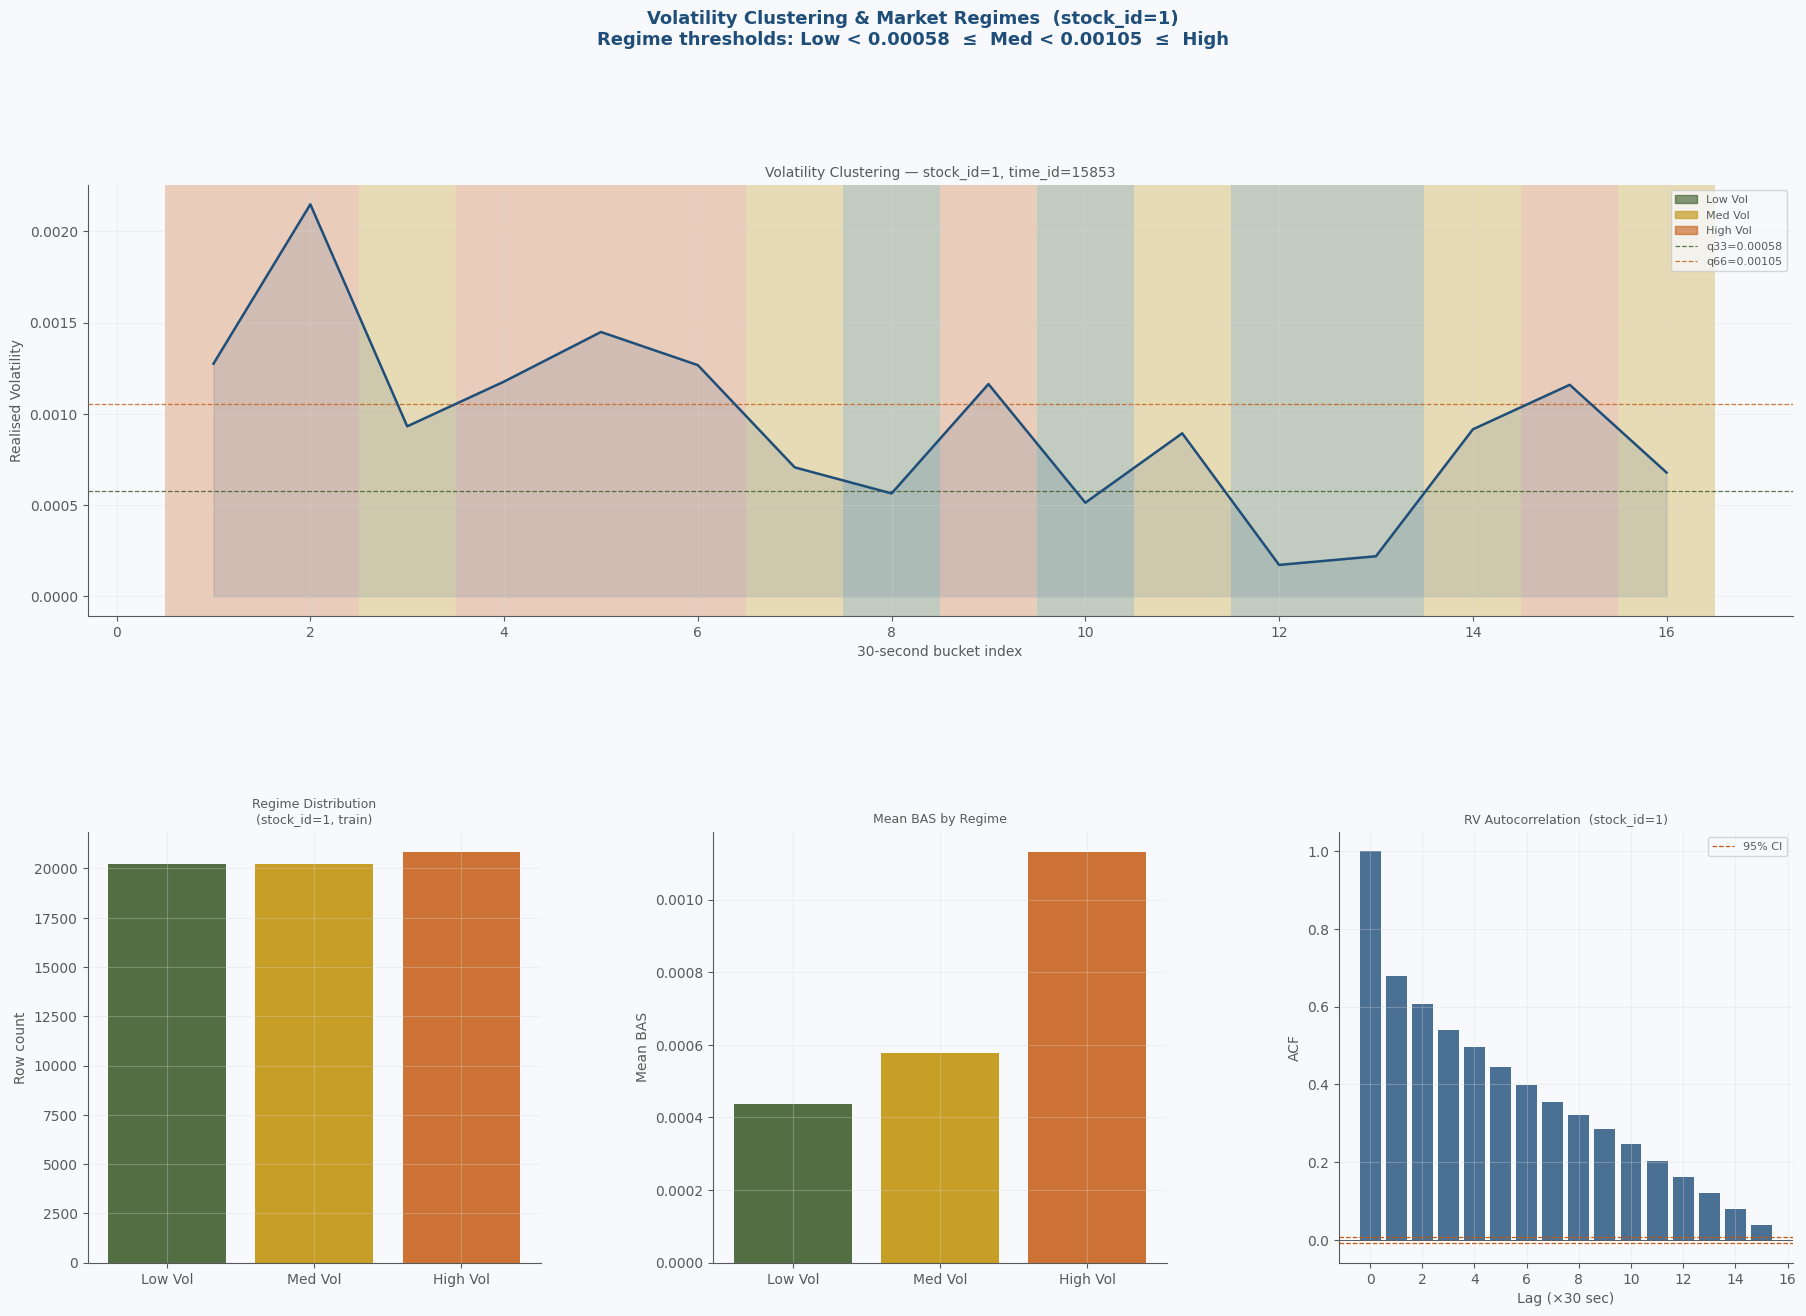

  Saved: cluster_plots.png  ✓

  OLS  MSE=0.00000003  QLIKE=-6.239762
  Tuning alpha …
  Best α = 0.99
  WLS  MSE=0.00000003  QLIKE=-6.239701


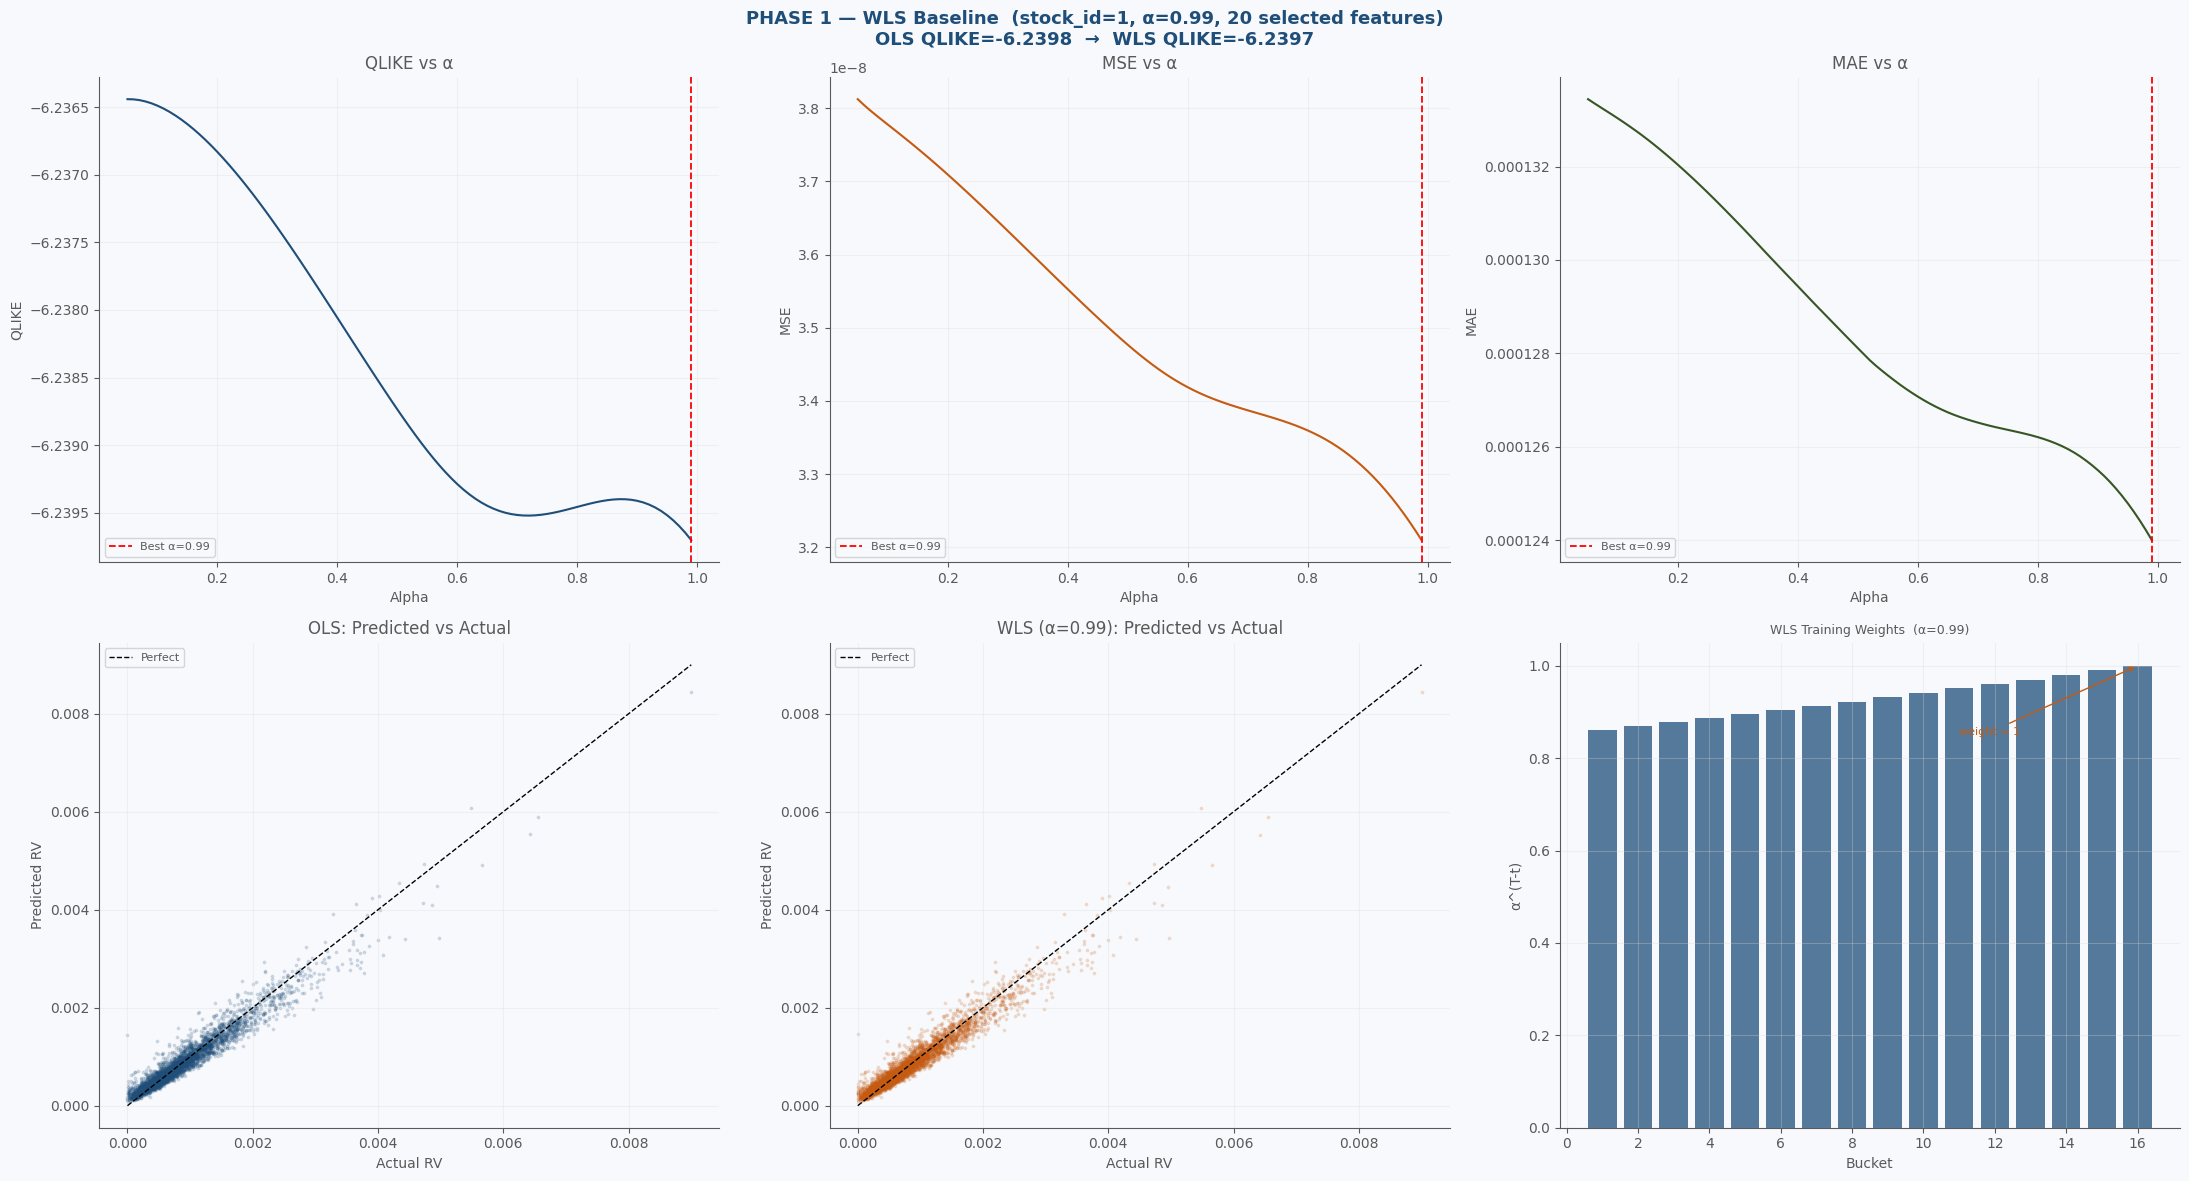

  Saved: phase1_wls_stock1.png  ✓

  ── PHASE 1 SUMMARY ──  OLS QLIKE=-6.239762  WLS QLIKE=-6.239701  α=0.99  features=20

██████████████████████████████████████████████████████████████████████
PHASE 2 — LIQUIDITY CLASSIFICATION  (all stocks)
██████████████████████████████████████████████████████████████████████
  Engineering features on full train (6,856,866 rows) …
  Global BAS thresholds  : Low < 0.000302  ≤  Med < 0.000637  ≤  High
  Global Activity thresh : Low < 7.3320   ≤  Med < 8.0801   ≤  High
    illiquid  :   43 stocks (38.4%)
    liquid    :   39 stocks (34.8%)
    mixed     :   30 stocks (26.8%)

  10 MOST LIQUID   stock_ids: [43, 29, 69, 111, 41, 124, 46, 47, 125, 14]
  10 MOST ILLIQUID stock_ids: [31, 18, 37, 75, 27, 33, 97, 112, 40, 9]

  ── 10 MOST LIQUID ──
 stock_id  liquid_pct  illiquid_pct  median_bas  median_log_activity recommended_model
       43    0.999951      0.000000    0.000045             9.994669          EGARCH-X
       29    0.999543      0.000000    0

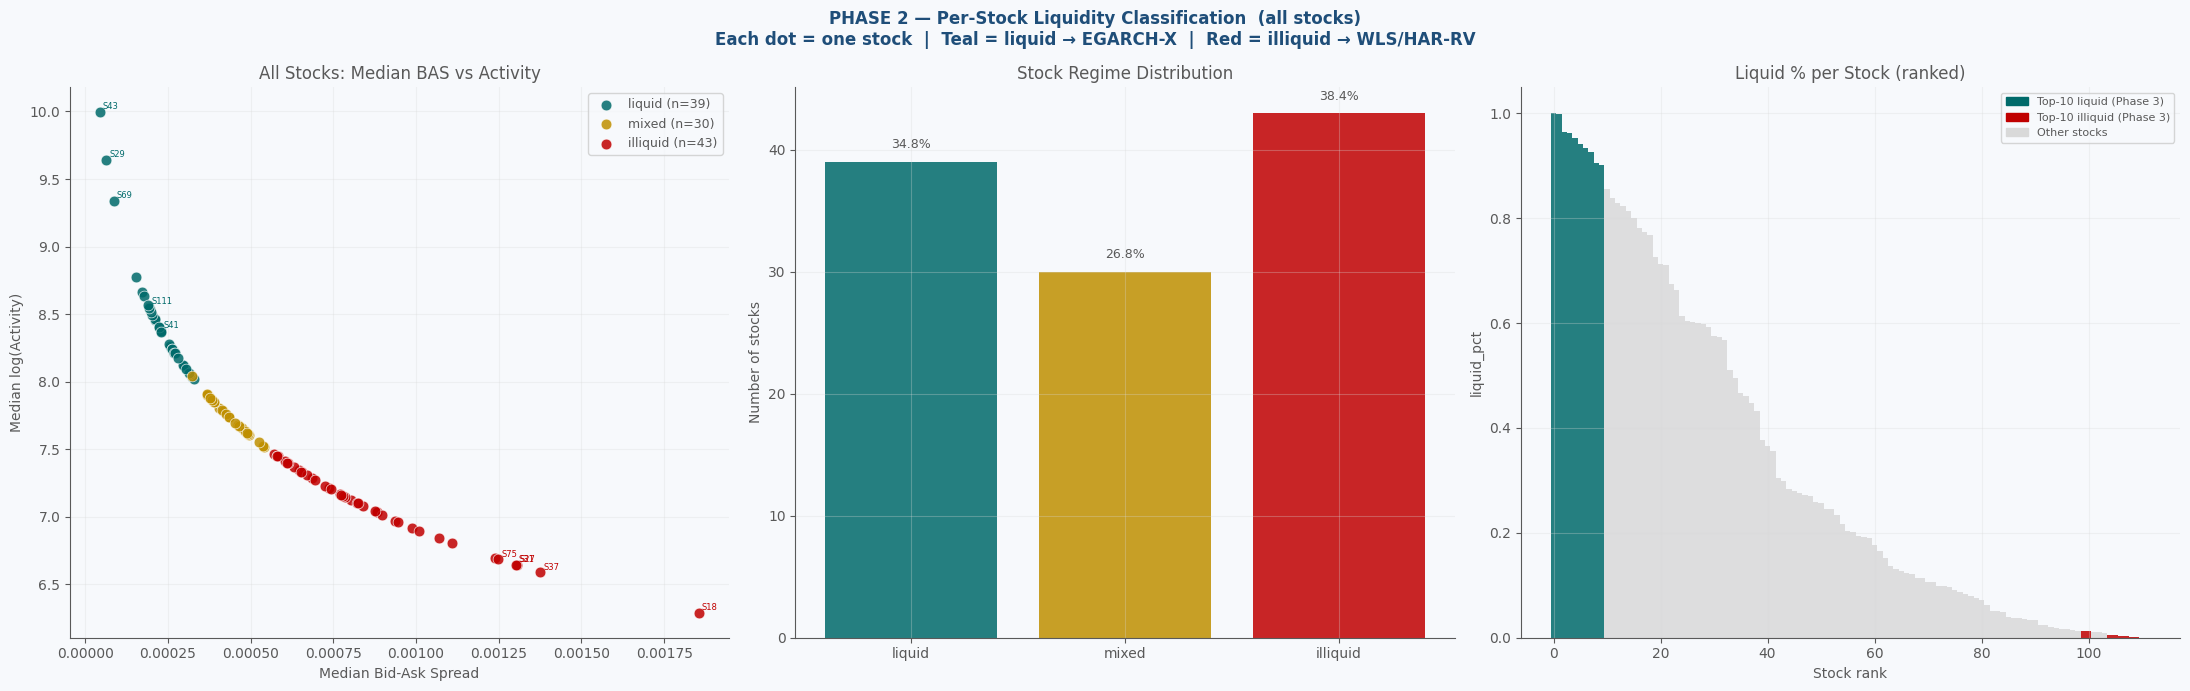

  Saved: phase2_all_stock_liquidity.png  ✓

██████████████████████████████████████████████████████████████████████
PHASE 3 — WLS ON 20 DEMO STOCKS  (10 liquid + 10 illiquid)
  Using 20 features selected in Phase 1
██████████████████████████████████████████████████████████████████████
  Engineering features …
  Tuning alpha …
  Best α = 0.96
  OLS QLIKE=-3.346712  WLS QLIKE=-3.374372

  ── PER-STOCK WLS RESULTS ──
  S43   liquid     WLS=-7.318615  OLS=-7.318551  BAS=0.000046  ← EGARCH-X
  S125  liquid     WLS=-7.084405  OLS=-7.084961  BAS=0.000218  ← EGARCH-X
  S46   liquid     WLS=-7.081876  OLS=-7.082278  BAS=0.000221  ← EGARCH-X
  S29   liquid     WLS=-7.022249  OLS=-7.022310  BAS=0.000067  ← EGARCH-X
  S41   liquid     WLS=-7.005500  OLS=-7.005998  BAS=0.000238  ← EGARCH-X
  S47   liquid     WLS=-6.970027  OLS=-6.970671  BAS=0.000238  ← EGARCH-X
  S111  liquid     WLS=-6.777138  OLS=-6.777490  BAS=0.000197  ← EGARCH-X
  S69   liquid     WLS=-6.773936  OLS=-6.774036  BAS=0.000107  ← 

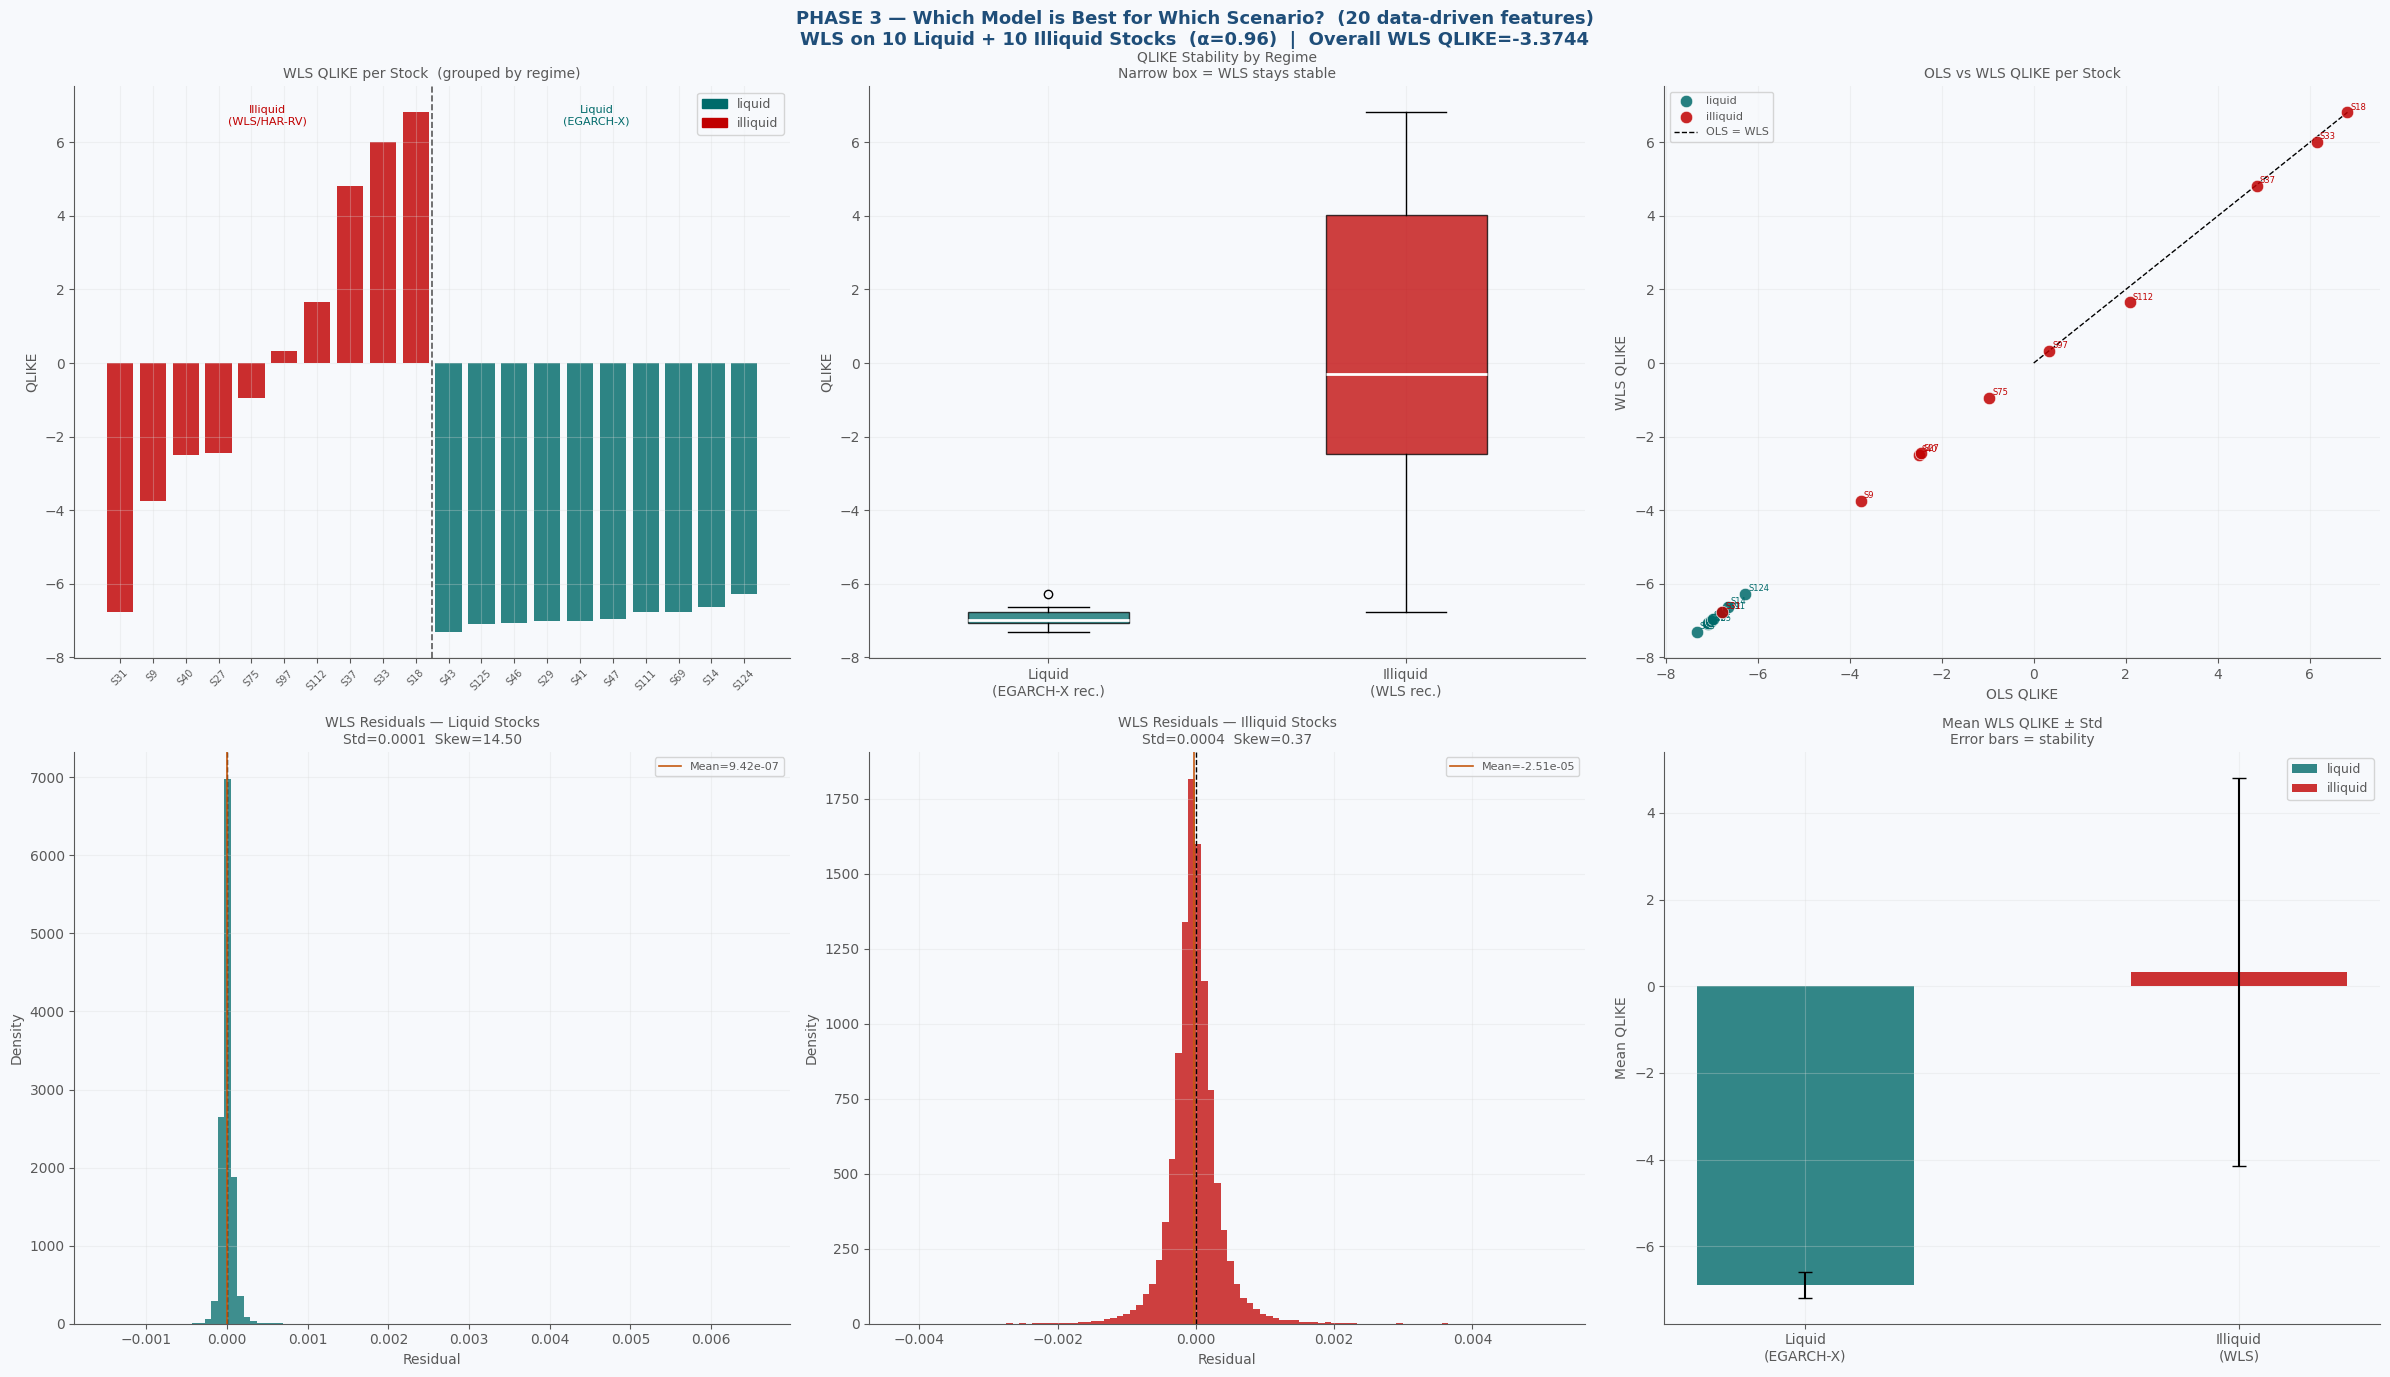

  Saved: phase3_scenario_comparison.png  ✓


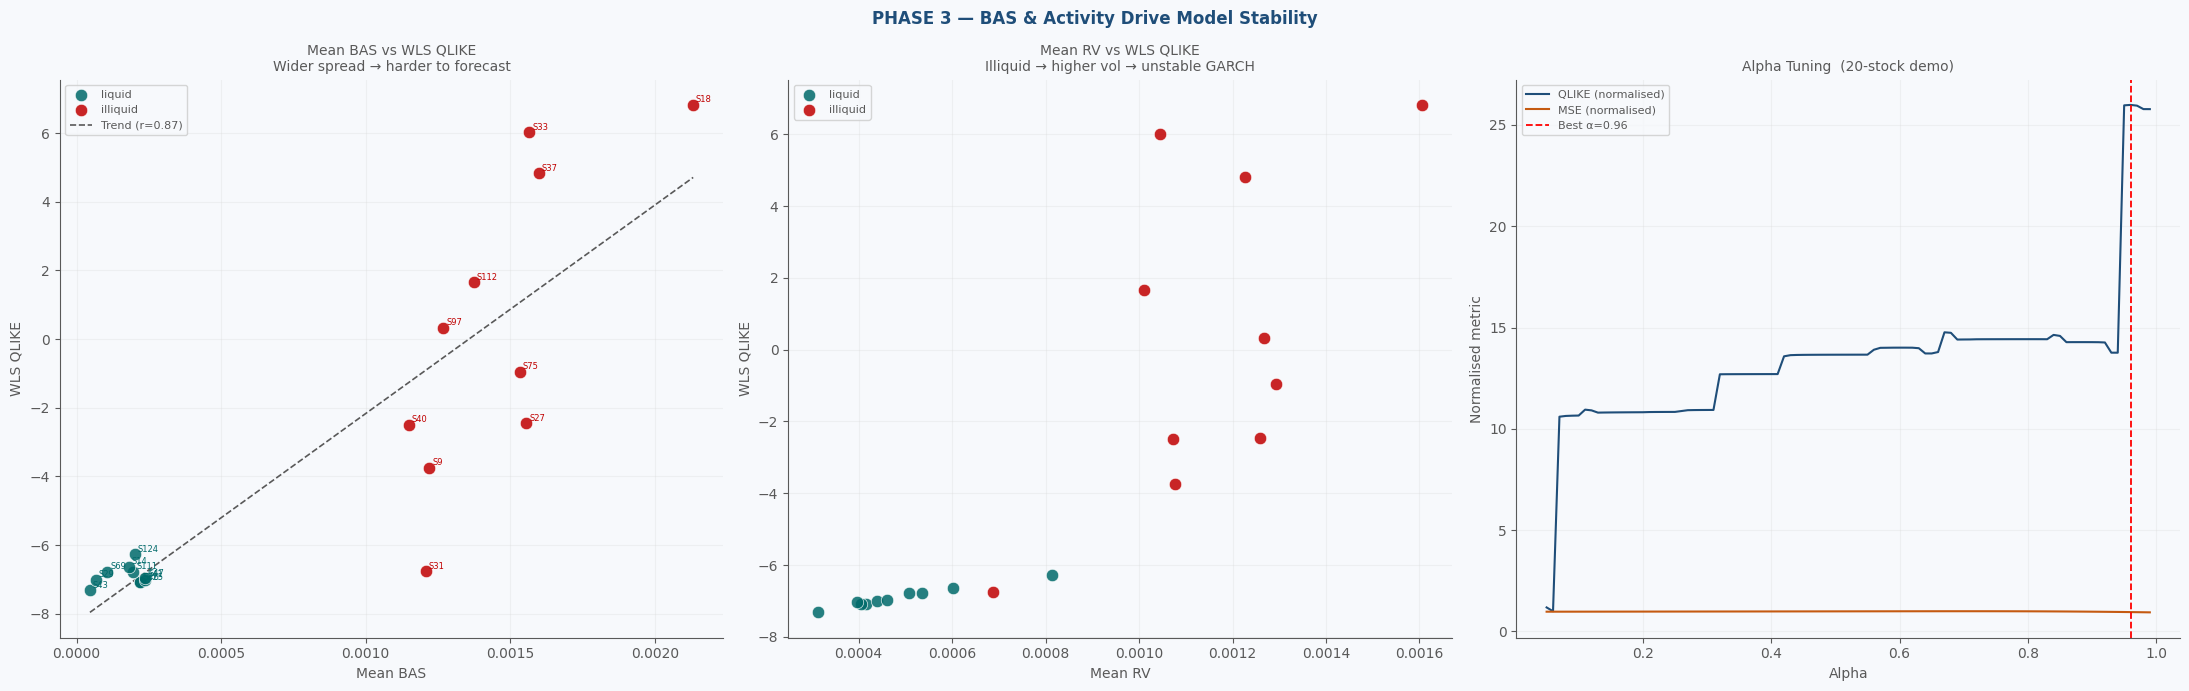

  Saved: phase3_bas_qlike_tradeoff.png  ✓
  Saved: m2_wls_predictions_demo20.csv  ✓
  Saved: m2_per_stock_eval_demo20.csv   ✓

██████████████████████████████████████████████████████████████████████
FINAL SUMMARY
██████████████████████████████████████████████████████████████████████
  Feature selection (data-driven on stock_id=1 training data):
    Candidate pool  : 32 features
    |r| threshold   : 0.05
    Collinearity cap: 0.95
    FINAL_FEATURES  : 20 → ['rv_roll_mean', 'bas', 'rv_lag1', 'bas_roll_mean', 'rv_lag2', 'rel_spread_lag1', 'log_activity', 'rv_lag3', 'rv_roll_sd', 'log_activity_lag1', 'rel_spread_vol', 'inv_spread', 'rv_lag1_sq', 'bas_roll_sd', 'inv_spread_lag1', 'bas_sq', 'rv_roll_cv', 'bas_pct_change', 'volume_surge', 'bas_change']

  Phase 1  (stock_id=1):  α=0.99  OLS QLIKE=-6.239762  WLS QLIKE=-6.239701
  Phase 2  (all stocks):  liquid=39  illiquid=43  mixed=30
  Phase 3  (20 stocks):   α=0.96  liquid std=0.292295  illiquid std=4.481291
  Liquid   stocks : [43, 29, 69

In [2]:
"""
Member 2 (Jamie): WLS Volatility Forecasting — Complete Three-Phase Pipeline
=============================================================================
FEATURE SELECTION is now data-driven:
  1. Compute Pearson |r| with RV on stock_id=1 training data
  2. Drop features with |r| < MIN_CORR_THRESHOLD (default 0.05)
  3. Drop one of each highly collinear pair (|r_pair| > COLLINEARITY_THRESHOLD)
  4. FINAL_FEATURES is derived from the data, not hardcoded

PHASE 1 — WLS Baseline on stock_id = 1
PHASE 2 — Liquidity Classification of ALL stocks
PHASE 3 — WLS on 20 Demo Stocks (10 liquid + 10 illiquid)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.linear_model import LinearRegression
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────
# PALETTE
# ─────────────────────────────────────────────────────────────────────
C_BLUE   = "#1F4E79"
C_ORANGE = "#C55A11"
C_GREEN  = "#375623"
C_PURPLE = "#7030A0"
C_GOLD   = "#BF8F00"
C_GREY   = "#595959"
C_LGREY  = "#D9D9D9"
C_BG     = "#F7F9FC"
C_RED    = "#C00000"
C_TEAL   = "#006A6A"
STOCK_COLORS = {"liquid": C_TEAL, "mixed": C_GOLD, "illiquid": C_RED}
LIQ_COLORS   = {"liquid": C_TEAL, "mixed": C_GOLD, "illiquid": C_RED}

plt.rcParams.update({
    "figure.facecolor":  C_BG,  "axes.facecolor":    C_BG,
    "axes.edgecolor":    C_GREY, "axes.labelcolor":   C_GREY,
    "xtick.color":       C_GREY, "ytick.color":       C_GREY,
    "text.color":        C_GREY, "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,  "axes.spines.right": False,
    "axes.grid":         True,   "grid.alpha":        0.3,
    "grid.color":        C_LGREY,
})

OUT = "/Users/jamiewood/Documents/DATA3888/DATA3888G08/"
N_DEMO_PER_REGIME = 10

# ─────────────────────────────────────────────────────────────────────
# FEATURE SELECTION THRESHOLDS  (only knobs you need to tune)
# ─────────────────────────────────────────────────────────────────────
MIN_CORR_THRESHOLD   = 0.05   # drop features with |r with RV| below this
COLLINEARITY_THRESHOLD = 0.95  # drop one of each pair with |r_pair| above this

BUCKET_SECONDS     = 30
WINDOW_SECONDS     = 600
N_EXPECTED_BUCKETS = WINDOW_SECONDS // BUCKET_SECONDS

TARGET = "rv"

# ─────────────────────────────────────────────────────────────────────
# CANDIDATE FEATURE POOL  (every engineered feature — selection picks from these)
# ─────────────────────────────────────────────────────────────────────
ALL_FEATURES = [
    "rv_lag1", "rv_lag2", "rv_lag3",
    "rv_roll_mean", "rv_roll_sd", "rv_roll_max", "rv_roll_cv",
    "bas", "bas_lag1", "rel_spread", "rel_spread_lag1",
    "bas_change", "bas_pct_change", "bas_roll_mean", "bas_roll_sd",
    "wap", "wap_return", "wap_return2", "wap_dev", "wap_accel",
    "inv_spread", "inv_spread_lag1", "log_activity", "log_activity_lag1",
    "spread_imbalance", "volume_surge",
    "spread_vol_interaction", "rel_spread_vol",
    "spread_change_vol", "activity_vol",
    "rv_lag1_sq", "bas_sq",
]

# ─────────────────────────────────────────────────────────────────────
# LOSS FUNCTIONS
# ─────────────────────────────────────────────────────────────────────
def qlike(y, yhat):
    yhat = np.maximum(yhat, 1e-8)
    return float(np.mean(np.log(yhat) + y / yhat))

def mse(y, yhat):  return float(np.mean((y - yhat) ** 2))
def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))

# ─────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING  (unchanged — generates the candidate pool)
# ─────────────────────────────────────────────────────────────────────
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df  = df.sort_values(["stock_id", "time_id", "time_bucket"]).copy()
    grp = df.groupby(["stock_id", "time_id"])
    df["rv_lag1"]      = grp["rv"].shift(1)
    df["rv_lag2"]      = grp["rv"].shift(2)
    df["rv_lag3"]      = grp["rv"].shift(3)
    df["rv_roll_mean"] = grp["rv"].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df["rv_roll_sd"]   = grp["rv"].transform(lambda x: x.rolling(5, min_periods=1).std())
    df["rv_roll_max"]  = grp["rv"].transform(lambda x: x.rolling(5, min_periods=1).max())
    df["rv_roll_cv"]   = df["rv_roll_sd"] / (df["rv_roll_mean"] + 1e-12)
    df["bas_lag1"]        = grp["bas"].shift(1)
    df["rel_spread"]      = df["bas"] / (df["wap"] + 1e-12)
    df["rel_spread_lag1"] = grp["rel_spread"].shift(1)
    df["bas_change"]      = df["bas"] - df["bas_lag1"]
    df["bas_pct_change"]  = df["bas_change"] / (df["bas_lag1"] + 1e-12)
    df["bas_roll_mean"]   = grp["bas"].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df["bas_roll_sd"]     = grp["bas"].transform(lambda x: x.rolling(5, min_periods=1).std())
    df["bas_sq"]          = df["bas"] ** 2
    df["wap_lag1"]      = grp["wap"].shift(1)
    df["wap_lag2"]      = grp["wap"].shift(2)
    df["wap_return"]    = np.log(df["wap"] / (df["wap_lag1"] + 1e-12))
    df["wap_return2"]   = np.log(df["wap"] / (df["wap_lag2"] + 1e-12))
    df["wap_roll_mean"] = grp["wap"].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df["wap_dev"]       = df["wap"] - df["wap_roll_mean"]
    df["wap_accel"]     = df["wap_return"] - grp["wap_return"].shift(1)
    df["inv_spread"]        = 1.0 / (df["bas"] + 1e-6)
    df["inv_spread_lag1"]   = grp["inv_spread"].shift(1)
    df["inv_spread_roll"]   = grp["inv_spread"].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df["activity_proxy"]    = df["wap"] * df["inv_spread"]
    df["log_activity"]      = np.log1p(df["activity_proxy"])
    df["log_activity_lag1"] = grp["log_activity"].shift(1)
    df["spread_imbalance"]  = df["bas_pct_change"]
    df["volume_surge"]      = df["inv_spread"] / (df["inv_spread_roll"] + 1e-12)
    df["spread_vol_interaction"] = df["bas"]          * df["rv_lag1"]
    df["rel_spread_vol"]         = df["rel_spread"]   * df["rv_lag1"]
    df["spread_change_vol"]      = df["bas_change"]   * df["rv_lag1"]
    df["activity_vol"]           = df["log_activity"] * df["rv_lag1"]
    df["wap_vol_interaction"]    = df["wap_return"]   * df["rv_lag1"]
    df["rv_lag1_sq"] = df["rv_lag1"] ** 2
    return df

# ─────────────────────────────────────────────────────────────────────
# DATA-DRIVEN FEATURE SELECTION
# ─────────────────────────────────────────────────────────────────────
def select_features(train_df, candidate_features, target,
                    min_corr=MIN_CORR_THRESHOLD,
                    collinearity_thresh=COLLINEARITY_THRESHOLD,
                    sample_n=50_000, random_state=42):
    """
    Returns FINAL_FEATURES derived from training data.

    Steps:
      1. Sample rows for speed (correlation is stable on 50k rows).
      2. Compute Pearson |r| between each candidate feature and target.
      3. Drop features where |r| < min_corr  (too weak to be useful).
      4. Among remaining features, drop one of each collinear pair
         where |r_pair| > collinearity_thresh, keeping the one with
         higher |r with target|.
      5. Return sorted list (strongest → weakest |r with RV|).
    """
    sample = train_df[candidate_features + [target]].dropna()
    if len(sample) > sample_n:
        sample = sample.sample(sample_n, random_state=random_state)

    # Step 2: target correlations
    rv_corrs = (sample.corr()[target]
                .drop(target)
                .reindex(candidate_features)
                .dropna())

    print(f"\n  [FEATURE SELECTION] Candidate pool : {len(rv_corrs)} features")

    # Step 3: weak-feature filter
    strong = rv_corrs[rv_corrs.abs() >= min_corr]
    dropped_weak = sorted(set(candidate_features) - set(strong.index) -
                          {f for f in candidate_features if f not in rv_corrs.index})
    print(f"  [FEATURE SELECTION] Dropped (|r| < {min_corr}): {dropped_weak}")

    # Step 4: collinearity pruning (greedy — keep higher |r_with_rv|)
    feature_corr = sample[strong.index.tolist()].corr().abs()
    kept = list(strong.index)
    dropped_collinear = []
    for i in range(len(kept)):
        if kept[i] is None:
            continue
        for j in range(i + 1, len(kept)):
            if kept[j] is None:
                continue
            if feature_corr.loc[kept[i], kept[j]] > collinearity_thresh:
                # drop whichever has lower |r with target|
                ri = abs(rv_corrs[kept[i]])
                rj = abs(rv_corrs[kept[j]])
                drop = kept[j] if ri >= rj else kept[i]
                dropped_collinear.append(drop)
                if drop == kept[i]:
                    kept[i] = None
                    break
                else:
                    kept[j] = None

    kept = [f for f in kept if f is not None]
    print(f"  [FEATURE SELECTION] Dropped (collinear > {collinearity_thresh}): {sorted(dropped_collinear)}")

    # Step 5: sort by |r with RV|, strongest first
    final = sorted(kept, key=lambda f: abs(rv_corrs[f]), reverse=True)
    print(f"  [FEATURE SELECTION] Final features ({len(final)}): {final}")
    return final, rv_corrs

# ─────────────────────────────────────────────────────────────────────
# SHARED PIPELINE HELPERS
# ─────────────────────────────────────────────────────────────────────
def train_val_split(df):
    sorted_b  = sorted(df["time_bucket"].unique())
    n_train   = int(len(sorted_b) * 0.8)
    train_max = sorted_b[n_train - 1]
    return (df[df["time_bucket"] <= train_max].copy(),
            df[df["time_bucket"] >  train_max].copy(),
            sorted_b, n_train, train_max)

def tune_alpha(X_tr, y_tr, X_te, y_te, train_max, bv):
    alpha_grid = np.round(np.arange(0.05, 1.00, 0.01), 3)
    def _fit(a):
        w    = a ** (train_max - bv)
        pred = np.maximum(LinearRegression().fit(X_tr, y_tr, sample_weight=w).predict(X_te), 1e-8)
        return {"alpha": a, "qlike": qlike(y_te, pred),
                "mse":   mse(y_te, pred), "mae": mae(y_te, pred)}
    results = Parallel(n_jobs=-1)([delayed(_fit)(a) for a in alpha_grid])
    tdf = pd.DataFrame(results)
    return float(tdf.loc[tdf["qlike"].idxmin(), "alpha"]), tdf

def label_bucket_liquidity(frame, bas_q33, bas_q66, act_q33, act_q66):
    def _label(r):
        if r["bas"] <= bas_q33 and r["log_activity"] >= act_q66: return "liquid"
        if r["bas"] >= bas_q66 and r["log_activity"] <= act_q33: return "illiquid"
        return "mixed"
    frame["bucket_liquidity"] = frame.apply(_label, axis=1)
    return frame

def feature_group_color(feat):
    if "rv" in feat and "spread" not in feat and "activity" not in feat: return C_BLUE
    if feat in ("bas","bas_lag1","rel_spread","rel_spread_lag1","bas_change",
                "bas_pct_change","bas_roll_mean","bas_roll_sd","bas_sq"):    return C_ORANGE
    if "activity" in feat or "inv_spread" in feat or "imbalance" in feat \
            or "volume_surge" in feat:                                        return C_GREEN
    if "wap" in feat:                                                         return C_GOLD
    return C_GREY

# ═════════════════════════════════════════════════════════════════════
# LOAD FULL DATASET
# ═════════════════════════════════════════════════════════════════════
print("=" * 70)
print("LOADING FULL DATASET")
print("=" * 70)
df_full = pd.read_csv(OUT + "optiver_aggregated.csv")
df_full = df_full[df_full["time_bucket"] > 0].copy()
df_full = df_full.rename(columns={
    "WAP_mean": "wap", "BidAskSpread_mean": "bas", "volatility": "rv"})
df_full = df_full.sort_values(["stock_id","time_id","time_bucket"]).reset_index(drop=True)
print(f"  Full dataset (bucket-0 dropped): {df_full.shape}")
print(f"  Unique stocks: {df_full['stock_id'].nunique()}")

# ═══════════════════════════════════════════════════════════════════════
# ██  PHASE 1 — WLS BASELINE  (stock_id = 1 only)  ████████████████████
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "█" * 70)
print("PHASE 1 — WLS BASELINE  (stock_id = 1)  +  DATA-DRIVEN FEATURE SELECTION")
print("█" * 70)

df1 = df_full[df_full["stock_id"] == 1].copy()
print(f"  stock_id=1 rows: {len(df1):,}")

train1, test1, sorted_b1, n_train1, train_max1 = train_val_split(df1)
print(f"  Train buckets: 1–{train_max1}  |  Val buckets: {train_max1+1}–20")
print(f"  Train rows: {len(train1):,}   Val rows: {len(test1):,}")

print("  Engineering features …")
train1 = add_features(train1);  test1 = add_features(test1)

# ── Liquidity thresholds ──────────────────────────────────────────────
bas_q33_1 = train1["bas"].quantile(0.33); bas_q66_1 = train1["bas"].quantile(0.66)
act_q33_1 = train1["log_activity"].quantile(0.33); act_q66_1 = train1["log_activity"].quantile(0.66)
train1 = label_bucket_liquidity(train1, bas_q33_1, bas_q66_1, act_q33_1, act_q66_1)
test1  = label_bucket_liquidity(test1,  bas_q33_1, bas_q66_1, act_q33_1, act_q66_1)

# ── DATA-DRIVEN FEATURE SELECTION ─────────────────────────────────────
print("\n  Running data-driven feature selection on stock_id=1 training data …")
FINAL_FEATURES, rv_corrs = select_features(
    train1, ALL_FEATURES, TARGET,
    min_corr=MIN_CORR_THRESHOLD,
    collinearity_thresh=COLLINEARITY_THRESHOLD,
)

print(f"\n  ── SELECTED FEATURES ({len(FINAL_FEATURES)}) ──")
print(f"  {'Feature':<30} {'|r with RV|':>12}  {'r':>8}  Group")
print("  " + "─" * 65)
for f in FINAL_FEATURES:
    r = rv_corrs.get(f, np.nan)
    grp = feature_group_color(f)
    grp_name = ("RV lags/rolling" if grp == C_BLUE else
                 "Bid-Ask Spread"  if grp == C_ORANGE else
                 "Order-flow"      if grp == C_GREEN else
                 "Price (WAP)"     if grp == C_GOLD else "Interaction/nonlinear")
    print(f"  {f:<30} {abs(r):>12.4f}  {r:>+8.4f}  {grp_name}")

# ── EDA sample ────────────────────────────────────────────────────────
eda1 = train1.sample(min(50_000, len(train1)), random_state=42)
rv_corrs_full = (eda1[ALL_FEATURES + [TARGET]].dropna().corr()[TARGET]
                 .drop(TARGET).sort_values(key=abs, ascending=False))

# ─────────────────────────────────────────────────────────────────────
# EDA PLOT 1 — Covariate distributions
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.patch.set_facecolor(C_BG)
fig.suptitle("EDA — Covariate Distributions  (stock_id=1, 30-second buckets)",
             fontsize=14, fontweight="bold", color=C_BLUE, y=1.01)

axes[0,0].hist(train1["rv"].dropna(), bins=100, color=C_BLUE, edgecolor="none", alpha=0.85)
axes[0,0].set_title("Realised Volatility  [TARGET]"); axes[0,0].set_xlabel("rv"); axes[0,0].set_ylabel("Count")
axes[0,1].hist(train1["bas"].dropna(), bins=100, color=C_ORANGE, edgecolor="none", alpha=0.85)
axes[0,1].set_title("Bid-Ask Spread  [SPREAD COVARIATE]"); axes[0,1].set_xlabel("bas")
axes[0,2].hist(eda1["rel_spread"].dropna(), bins=80, color=C_PURPLE, edgecolor="none", alpha=0.85)
axes[0,2].set_title("Relative Spread = BAS / WAP  [NORMALISED SPREAD]"); axes[0,2].set_xlabel("rel_spread")
axes[1,0].hist(eda1["log_activity"].dropna(), bins=100, color=C_GREEN, edgecolor="none", alpha=0.85)
axes[1,0].set_title("log(Activity Proxy)  [ORDER-FLOW COVARIATE]"); axes[1,0].set_xlabel("log_activity")
axes[1,1].hist(eda1["inv_spread"].dropna(), bins=80, color=C_GOLD, edgecolor="none", alpha=0.85)
axes[1,1].set_title("Inverse Spread  [NUM-ORDERS PROXY]"); axes[1,1].set_xlabel("inv_spread")
axes[1,2].scatter(eda1["rv_lag1"], eda1["rv"], alpha=0.1, s=3, color=C_BLUE)
axes[1,2].set_title("RV Lag-1 vs RV  (persistence)"); axes[1,2].set_xlabel("rv_lag1"); axes[1,2].set_ylabel("rv")

plt.tight_layout()
plt.savefig(OUT + "eda_distributions.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: eda_distributions.png  ✓")

# ─────────────────────────────────────────────────────────────────────
# EDA PLOT 2 — Feature selection: full candidate correlations + selected overlay
# Shows ALL candidate features, with selected ones highlighted
# ─────────────────────────────────────────────────────────────────────
top_n        = min(len(rv_corrs_full), 28)
rv_corrs_top = rv_corrs_full.head(top_n)

# colour: selected = full saturation, dropped = desaturated grey
bar_colors = []
for f in rv_corrs_top.index:
    if f in FINAL_FEATURES:
        bar_colors.append(feature_group_color(f))
    else:
        bar_colors.append(C_LGREY)   # dropped feature → grey

fig, ax = plt.subplots(figsize=(15, 9))
fig.patch.set_facecolor(C_BG); ax.set_facecolor(C_BG)
bars = ax.barh(range(top_n), rv_corrs_top.values.astype(float),
               color=bar_colors, alpha=0.88, edgecolor="none")
ax.set_yticks(range(top_n))
ax.set_yticklabels(
    [f"★ {f}" if f in FINAL_FEATURES else f"  {f}" for f in rv_corrs_top.index],
    fontsize=8
)
ax.invert_yaxis()
ax.axvline(0, color=C_GREY, linewidth=0.8)
ax.axvline( MIN_CORR_THRESHOLD, color=C_RED, linestyle=":", lw=1.2,
            label=f"|r| threshold = {MIN_CORR_THRESHOLD} (features below → dropped)")
ax.axvline(-MIN_CORR_THRESHOLD, color=C_RED, linestyle=":", lw=1.2)
ax.set_xlabel("Pearson r with Realised Volatility", fontsize=10)
ax.set_title(
    f"Feature Selection — Correlation with RV  (stock_id=1, DATA-DRIVEN)\n"
    f"★ = selected ({len(FINAL_FEATURES)} features)  |  Grey = dropped  |  "
    f"Threshold: |r| ≥ {MIN_CORR_THRESHOLD}, collinearity < {COLLINEARITY_THRESHOLD}",
    fontsize=11, fontweight="bold", color=C_BLUE
)
legend_items = [
    mpatches.Patch(color=C_BLUE,   label="RV lags / rolling  ★ selected"),
    mpatches.Patch(color=C_ORANGE, label="Bid-Ask Spread      ★ selected"),
    mpatches.Patch(color=C_GREEN,  label="Order-flow proxies  ★ selected"),
    mpatches.Patch(color=C_GOLD,   label="Price (WAP)         ★ selected"),
    mpatches.Patch(color=C_GREY,   label="Interaction/nonlinear ★ selected"),
    mpatches.Patch(color=C_LGREY,  label="Dropped (weak or collinear)"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(OUT + "feature_selection_correlation.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: feature_selection_correlation.png  ✓")

# ─────────────────────────────────────────────────────────────────────
# EDA PLOT 3 — Correlation heatmap
# ─────────────────────────────────────────────────────────────────────
# Use FINAL_FEATURES (data-driven) + target for heatmap
heatmap_cols = [TARGET] + FINAL_FEATURES[:12]   # cap at 13 for readability
corr_matrix  = eda1[heatmap_cols].dropna().corr()

plt.figure(figsize=(14, 12)); plt.gca().set_facecolor(C_BG)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, mask=mask, linewidths=0.4, annot_kws={"size": 8})
plt.title(f"Correlation Matrix — Selected Covariates  (stock_id=1, top {len(heatmap_cols)-1} features)\n"
          "(Price  ·  Bid-Ask Spread  ·  Order-Flow  ·  RV Lags)",
          fontsize=12, fontweight="bold", color=C_BLUE)
plt.tight_layout()
plt.savefig(OUT + "correlation_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: correlation_heatmap.png  ✓")

# ─────────────────────────────────────────────────────────────────────
# EDA PLOT 4 — Spread features
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5)); fig.patch.set_facecolor(C_BG)
fig.suptitle("Bid-Ask Spread Covariate Analysis  (stock_id=1)", fontsize=13, fontweight="bold", color=C_BLUE)
axes[0].scatter(eda1["rel_spread"], eda1["rv"], alpha=0.1, s=3, color=C_PURPLE)
axes[0].set_title("Relative Spread vs RV"); axes[0].set_xlabel("rel_spread"); axes[0].set_ylabel("rv")
axes[1].scatter(eda1["bas_change"], eda1["rv"], alpha=0.1, s=3, color=C_ORANGE)
axes[1].set_title("Spread Change vs RV"); axes[1].set_xlabel("bas_change"); axes[1].set_ylabel("rv")
axes[2].scatter(eda1["spread_vol_interaction"], eda1["rv"], alpha=0.1, s=3, color=C_GREEN)
axes[2].set_title("Spread × Lagged Vol vs RV"); axes[2].set_xlabel("spread_vol_interaction"); axes[2].set_ylabel("rv")
plt.tight_layout()
plt.savefig(OUT + "spread_features_eda.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: spread_features_eda.png  ✓")

# ─────────────────────────────────────────────────────────────────────
# EDA PLOT 5 — Order-flow proxies
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5)); fig.patch.set_facecolor(C_BG)
fig.suptitle("Order-Flow Proxy & Activity Analysis  (stock_id=1)", fontsize=13, fontweight="bold", color=C_BLUE)
axes[0].scatter(eda1["inv_spread"], eda1["rv"], alpha=0.1, s=3, color=C_PURPLE)
axes[0].set_title("Inv Spread vs RV"); axes[0].set_xlabel("inv_spread"); axes[0].set_ylabel("rv")
axes[1].scatter(eda1["log_activity"], eda1["rv"], alpha=0.1, s=3, color=C_GREEN)
axes[1].set_title("log(Activity) vs RV"); axes[1].set_xlabel("log_activity"); axes[1].set_ylabel("rv")
axes[2].scatter(eda1["volume_surge"], eda1["rv"], alpha=0.1, s=3, color=C_GOLD)
axes[2].set_title("Volume Surge vs RV"); axes[2].set_xlabel("volume_surge"); axes[2].set_ylabel("rv")
plt.tight_layout()
plt.savefig(OUT + "order_flow_features_eda.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: order_flow_features_eda.png  ✓")

# ─────────────────────────────────────────────────────────────────────
# EDA PLOT 6 — Liquidity regime EDA + clustering + ACF
# ─────────────────────────────────────────────────────────────────────
q33 = train1["rv"].quantile(0.33); q66 = train1["rv"].quantile(0.66)
def classify_regime(v):
    if v <= q33: return 0
    if v <= q66: return 1
    return 2
train1["regime"] = train1["rv"].apply(classify_regime)
test1["regime"]  = test1["rv"].apply(classify_regime)
REG_COLORS = {0: C_GREEN, 1: C_GOLD, 2: C_ORANGE}
REG_LABELS = {0: "Low Vol", 1: "Med Vol", 2: "High Vol"}
bc1 = train1["bucket_liquidity"].value_counts()
liq_labels = ["liquid", "mixed", "illiquid"]

sample_tids = train1["time_id"].unique()
sample_tid  = sample_tids[len(sample_tids) // 2]
sample_ts   = train1[train1["time_id"] == sample_tid].sort_values("time_bucket")

fig = plt.figure(figsize=(22, 18)); fig.patch.set_facecolor(C_BG)
fig.suptitle("Liquidity Regime EDA — Identifying Liquid vs Illiquid Market Conditions\n"
             "Jamie (Member 2) · stock_id=1 · Supports dynamic model selection in trading app",
             fontsize=13, fontweight="bold", color=C_BLUE, y=1.005)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.40)

ax_sc = fig.add_subplot(gs[0, :2])
for regime, color in LIQ_COLORS.items():
    sub = eda1[eda1["bucket_liquidity"] == regime]
    ax_sc.scatter(sub["bas"], sub["log_activity"], alpha=0.20, s=4, color=color,
                  label=f"{regime}  (n={len(sub):,})")
ax_sc.axvline(bas_q33_1, color=C_TEAL, linestyle="--", lw=1.0, alpha=0.8, label=f"BAS q33={bas_q33_1:.5f}")
ax_sc.axvline(bas_q66_1, color=C_RED,  linestyle="--", lw=1.0, alpha=0.8, label=f"BAS q66={bas_q66_1:.5f}")
ax_sc.axhline(act_q33_1, color=C_RED,  linestyle=":",  lw=1.0, alpha=0.8, label=f"Activity q33={act_q33_1:.2f}")
ax_sc.axhline(act_q66_1, color=C_TEAL, linestyle=":",  lw=1.0, alpha=0.8, label=f"Activity q66={act_q66_1:.2f}")
ax_sc.set_title("BAS vs log(Activity) — Bucket Liquidity Classification  (stock_id=1)",
                fontsize=10, color=C_GREY)
ax_sc.set_xlabel("Bid-Ask Spread (BAS)"); ax_sc.set_ylabel("log(Activity Proxy)")
ax_sc.legend(fontsize=8, loc="upper right")

ax_reg = fig.add_subplot(gs[0, 2])
liq_cnts = [bc1.get(l, 0) for l in liq_labels]
ax_reg.bar(liq_labels, liq_cnts, color=[LIQ_COLORS[l] for l in liq_labels], alpha=0.85, edgecolor="none")
ax_reg.set_title("Bucket Liquidity\nDistribution (train)", fontsize=9, color=C_GREY)
ax_reg.set_ylabel("Row count")
for i, (lbl, cnt) in enumerate(zip(liq_labels, liq_cnts)):
    pct = 100 * cnt / sum(liq_cnts)
    ax_reg.text(i, cnt + max(liq_cnts)*0.01, f"{pct:.1f}%", ha="center", fontsize=8, color=C_GREY)

ax_rv = fig.add_subplot(gs[1, 0])
for regime, color in LIQ_COLORS.items():
    vals = eda1.loc[eda1["bucket_liquidity"] == regime, "rv"].dropna()
    ax_rv.hist(vals, bins=60, color=color, alpha=0.55, edgecolor="none", label=regime, density=True)
ax_rv.set_title("RV Distribution\nby Liquidity Regime", fontsize=9, color=C_GREY)
ax_rv.set_xlabel("Realised Volatility"); ax_rv.set_ylabel("Density"); ax_rv.legend(fontsize=8)

ax_bas = fig.add_subplot(gs[1, 1])
for regime, color in LIQ_COLORS.items():
    vals = eda1.loc[eda1["bucket_liquidity"] == regime, "bas"].dropna()
    ax_bas.hist(vals, bins=60, color=color, alpha=0.55, edgecolor="none", label=regime, density=True)
ax_bas.set_title("BAS Distribution\nby Liquidity Regime", fontsize=9, color=C_GREY)
ax_bas.set_xlabel("Bid-Ask Spread"); ax_bas.set_ylabel("Density"); ax_bas.legend(fontsize=8)

ax_mrv = fig.add_subplot(gs[1, 2])
mean_rv_by_regime = eda1.groupby("bucket_liquidity")["rv"].mean()
ax_mrv.bar([l for l in liq_labels if l in mean_rv_by_regime.index],
           [mean_rv_by_regime.get(l, 0) for l in liq_labels if l in mean_rv_by_regime.index],
           color=[LIQ_COLORS[l] for l in liq_labels if l in mean_rv_by_regime.index],
           alpha=0.85, edgecolor="none")
ax_mrv.set_title("Mean RV by Liquidity Regime\n(illiquid = higher vol, GARCH can diverge)",
                 fontsize=9, color=C_GREY)
ax_mrv.set_ylabel("Mean Realised Volatility")

ax_ts = fig.add_subplot(gs[2, :2])
for _, row in sample_ts.iterrows():
    ax_ts.axvspan(row["time_bucket"]-0.5, row["time_bucket"]+0.5,
                  color=REG_COLORS[row["regime"]], alpha=0.28, linewidth=0)
ax_ts.plot(sample_ts["time_bucket"], sample_ts["rv"], color=C_BLUE, lw=1.8, zorder=3, label="RV")
ax_ts.fill_between(sample_ts["time_bucket"], sample_ts["rv"], alpha=0.12, color=C_BLUE)
ax_ts.axhline(q33, color=C_GREEN,  linestyle="--", lw=0.9, alpha=0.8, label=f"q33={q33:.5f}")
ax_ts.axhline(q66, color=C_ORANGE, linestyle="--", lw=0.9, alpha=0.8, label=f"q66={q66:.5f}")
ax_ts.set_title(f"Volatility Clustering — stock_id=1, time_id={sample_tid}", fontsize=9, color=C_GREY)
ax_ts.set_xlabel("30-second bucket index"); ax_ts.set_ylabel("Realised Volatility")
regime_patches = [mpatches.Patch(color=REG_COLORS[r], alpha=0.6, label=REG_LABELS[r]) for r in [0,1,2]]
ax_ts.legend(handles=regime_patches + ax_ts.get_legend_handles_labels()[0][1:], loc="upper right", fontsize=8)

ax_acf = fig.add_subplot(gs[2, 2])
rv_series = train1.sort_values(["time_id","time_bucket"])["rv"].dropna().values
MAX_LAG   = 15
acf_vals  = np.array([np.corrcoef(rv_series[:-lag], rv_series[lag:])[0,1]
                      if lag > 0 else 1.0 for lag in range(MAX_LAG+1)])
ci = 1.96 / np.sqrt(len(rv_series))
ax_acf.bar(range(MAX_LAG+1), acf_vals, color=C_BLUE, alpha=0.8, edgecolor="none")
ax_acf.axhline( ci, color=C_ORANGE, linestyle="--", lw=0.9, label="95% CI")
ax_acf.axhline(-ci, color=C_ORANGE, linestyle="--", lw=0.9)
ax_acf.axhline(0,   color=C_GREY,   linewidth=0.7)
ax_acf.set_title("RV Autocorrelation  (stock_id=1)\n→ strong persistence justifies rv_lag1, rv_lag2",
                 fontsize=9, color=C_GREY); ax_acf.set_xlabel("Lag (×30 sec)"); ax_acf.set_ylabel("ACF")
ax_acf.legend(fontsize=8)

plt.savefig(OUT + "liquidity_regime_eda.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: liquidity_regime_eda.png  ✓")

# ─────────────────────────────────────────────────────────────────────
# EDA PLOT 7 — Standalone cluster plots
# ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 14)); fig.patch.set_facecolor(C_BG)
fig.suptitle(f"Volatility Clustering & Market Regimes  (stock_id=1)\n"
             f"Regime thresholds: Low < {q33:.5f}  ≤  Med < {q66:.5f}  ≤  High",
             fontsize=13, fontweight="bold", color=C_BLUE, y=1.005)
gs2 = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

ax_ts2 = fig.add_subplot(gs2[0, :])
for _, row in sample_ts.iterrows():
    ax_ts2.axvspan(row["time_bucket"]-0.5, row["time_bucket"]+0.5,
                   color=REG_COLORS[row["regime"]], alpha=0.28, linewidth=0)
ax_ts2.plot(sample_ts["time_bucket"], sample_ts["rv"], color=C_BLUE, lw=1.8, zorder=3, label="RV")
ax_ts2.fill_between(sample_ts["time_bucket"], sample_ts["rv"], alpha=0.12, color=C_BLUE)
ax_ts2.axhline(q33, color=C_GREEN,  linestyle="--", lw=0.9, alpha=0.8, label=f"q33={q33:.5f}")
ax_ts2.axhline(q66, color=C_ORANGE, linestyle="--", lw=0.9, alpha=0.8, label=f"q66={q66:.5f}")
ax_ts2.set_title(f"Volatility Clustering — stock_id=1, time_id={sample_tid}",
                 fontsize=10, color=C_GREY)
ax_ts2.set_xlabel("30-second bucket index"); ax_ts2.set_ylabel("Realised Volatility")
regime_patches2 = [mpatches.Patch(color=REG_COLORS[r], alpha=0.6, label=REG_LABELS[r]) for r in [0,1,2]]
ax_ts2.legend(handles=regime_patches2 + ax_ts2.get_legend_handles_labels()[0][1:],
              loc="upper right", fontsize=8)

ax_reg2 = fig.add_subplot(gs2[1, 0])
counts = train1["regime"].value_counts().sort_index()
ax_reg2.bar([REG_LABELS[r] for r in counts.index], counts.values,
            color=[REG_COLORS[r] for r in counts.index], alpha=0.85, edgecolor="none")
ax_reg2.set_title("Regime Distribution\n(stock_id=1, train)", fontsize=9, color=C_GREY)
ax_reg2.set_ylabel("Row count")

ax_bas2 = fig.add_subplot(gs2[1, 1])
bas_reg = train1.groupby("regime")["bas"].mean()
ax_bas2.bar([REG_LABELS[r] for r in bas_reg.index], bas_reg.values,
            color=[REG_COLORS[r] for r in bas_reg.index], alpha=0.85, edgecolor="none")
ax_bas2.set_title("Mean BAS by Regime", fontsize=9, color=C_GREY); ax_bas2.set_ylabel("Mean BAS")

ax_acf2 = fig.add_subplot(gs2[1, 2])
ax_acf2.bar(range(MAX_LAG+1), acf_vals, color=C_BLUE, alpha=0.8, edgecolor="none")
ax_acf2.axhline( ci, color=C_ORANGE, linestyle="--", lw=0.9, label="95% CI")
ax_acf2.axhline(-ci, color=C_ORANGE, linestyle="--", lw=0.9)
ax_acf2.axhline(0,   color=C_GREY,   linewidth=0.7)
ax_acf2.set_title("RV Autocorrelation  (stock_id=1)", fontsize=9, color=C_GREY)
ax_acf2.set_xlabel("Lag (×30 sec)"); ax_acf2.set_ylabel("ACF"); ax_acf2.legend(fontsize=8)

plt.savefig(OUT + "cluster_plots.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: cluster_plots.png  ✓")

# ── WLS MODEL (using data-driven FINAL_FEATURES) ──────────────────────
tr1c = train1.dropna(subset=FINAL_FEATURES + [TARGET])
te1c = test1.dropna(subset=FINAL_FEATURES + [TARGET])
X_tr1, y_tr1 = tr1c[FINAL_FEATURES].values, tr1c[TARGET].values
X_te1, y_te1 = te1c[FINAL_FEATURES].values, te1c[TARGET].values
bv1          = tr1c["time_bucket"].values

ols1      = LinearRegression().fit(X_tr1, y_tr1)
ols1_pred = np.maximum(ols1.predict(X_te1), 1e-8)
print(f"\n  OLS  MSE={mse(y_te1,ols1_pred):.8f}  QLIKE={qlike(y_te1,ols1_pred):.6f}")

print("  Tuning alpha …")
best_alpha1, tune_df1 = tune_alpha(X_tr1, y_tr1, X_te1, y_te1, train_max1, bv1)
print(f"  Best α = {best_alpha1:.2f}")

w1        = best_alpha1 ** (train_max1 - bv1)
wls1      = LinearRegression().fit(X_tr1, y_tr1, sample_weight=w1)
wls1_pred = np.maximum(wls1.predict(X_te1), 1e-8)
print(f"  WLS  MSE={mse(y_te1,wls1_pred):.8f}  QLIKE={qlike(y_te1,wls1_pred):.6f}")

# Phase 1 model diagnostic plot
fig, axes = plt.subplots(2, 3, figsize=(22, 12)); fig.patch.set_facecolor(C_BG)
fig.suptitle(f"PHASE 1 — WLS Baseline  (stock_id=1, α={best_alpha1:.2f}, {len(FINAL_FEATURES)} selected features)\n"
             f"OLS QLIKE={qlike(y_te1,ols1_pred):.4f}  →  WLS QLIKE={qlike(y_te1,wls1_pred):.4f}",
             fontsize=13, fontweight="bold", color=C_BLUE)

for ax, metric, color in zip(axes[0,:], ["qlike","mse","mae"], [C_BLUE, C_ORANGE, C_GREEN]):
    ax.plot(tune_df1["alpha"], tune_df1[metric], color=color, lw=1.5)
    ax.axvline(best_alpha1, color="red", linestyle="--", lw=1.3, label=f"Best α={best_alpha1:.2f}")
    ax.set_title(f"{metric.upper()} vs α"); ax.set_xlabel("Alpha"); ax.set_ylabel(metric.upper())
    ax.legend(fontsize=8); ax.set_facecolor(C_BG)

for ax, pred, label, color in zip(
    [axes[1,0], axes[1,1]], [ols1_pred, wls1_pred],
    ["OLS", f"WLS (α={best_alpha1:.2f})"], [C_BLUE, C_ORANGE]
):
    ax.set_facecolor(C_BG)
    idx = np.random.choice(len(y_te1), min(5000, len(y_te1)), replace=False)
    ax.scatter(y_te1[idx], pred[idx], alpha=0.15, s=3, color=color)
    lim = max(y_te1.max(), pred.max())
    ax.plot([0,lim],[0,lim], "k--", lw=1, label="Perfect")
    ax.set_title(f"{label}: Predicted vs Actual"); ax.set_xlabel("Actual RV")
    ax.set_ylabel("Predicted RV"); ax.legend(fontsize=8)

ax_w = axes[1,2]; ax_w.set_facecolor(C_BG)
t_v  = np.array(sorted_b1[:n_train1])
ax_w.bar(t_v, best_alpha1**(train_max1-t_v), color=C_BLUE, alpha=0.75, edgecolor="none", width=0.8)
ax_w.set_title(f"WLS Training Weights  (α={best_alpha1:.2f})", fontsize=9, color=C_GREY)
ax_w.set_xlabel("Bucket"); ax_w.set_ylabel("α^(T-t)")
ax_w.annotate("weight = 1", xy=(train_max1, 1), xytext=(train_max1-5, 0.85),
              arrowprops=dict(arrowstyle="->", color=C_ORANGE), color=C_ORANGE, fontsize=8)

plt.tight_layout()
plt.savefig(OUT + "phase1_wls_stock1.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: phase1_wls_stock1.png  ✓")
print(f"\n  ── PHASE 1 SUMMARY ──  OLS QLIKE={qlike(y_te1,ols1_pred):.6f}  "
      f"WLS QLIKE={qlike(y_te1,wls1_pred):.6f}  α={best_alpha1:.2f}  features={len(FINAL_FEATURES)}")

# ═══════════════════════════════════════════════════════════════════════
# ██  PHASE 2 — LIQUIDITY CLASSIFICATION  (all stocks)  ████████████████
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "█" * 70)
print("PHASE 2 — LIQUIDITY CLASSIFICATION  (all stocks)")
print("█" * 70)

train_all, _, _, _, _ = train_val_split(df_full)
print(f"  Engineering features on full train ({len(train_all):,} rows) …")
train_all_feat = add_features(train_all)

bas_q33_g = train_all_feat["bas"].quantile(0.33); bas_q66_g = train_all_feat["bas"].quantile(0.66)
act_q33_g = train_all_feat["log_activity"].quantile(0.33); act_q66_g = train_all_feat["log_activity"].quantile(0.66)
print(f"  Global BAS thresholds  : Low < {bas_q33_g:.6f}  ≤  Med < {bas_q66_g:.6f}  ≤  High")
print(f"  Global Activity thresh : Low < {act_q33_g:.4f}   ≤  Med < {act_q66_g:.4f}   ≤  High")

train_all_feat = label_bucket_liquidity(train_all_feat, bas_q33_g, bas_q66_g, act_q33_g, act_q66_g)

stock_liq = (
    train_all_feat.groupby("stock_id").agg(
        median_bas          = ("bas",              "median"),
        median_log_activity = ("log_activity",     "median"),
        median_rv           = ("rv",               "median"),
        mean_rv             = ("rv",               "mean"),
        rv_std              = ("rv",               "std"),
        liquid_pct          = ("bucket_liquidity", lambda x: (x == "liquid").mean()),
        illiquid_pct        = ("bucket_liquidity", lambda x: (x == "illiquid").mean()),
        mixed_pct           = ("bucket_liquidity", lambda x: (x == "mixed").mean()),
        n_buckets           = ("rv",               "count"),
    ).reset_index()
)

def _regime(row):
    if row["liquid_pct"]   >= 0.40: return "liquid"
    if row["illiquid_pct"] >= 0.40: return "illiquid"
    return "mixed"
def _model(regime): return "EGARCH-X" if regime == "liquid" else "WLS / HAR-RV"

stock_liq["stock_regime"]      = stock_liq.apply(_regime, axis=1)
stock_liq["recommended_model"] = stock_liq["stock_regime"].apply(_model)
rc = stock_liq["stock_regime"].value_counts()

for r, c in rc.items():
    print(f"    {r:<10}: {c:>4} stocks ({100*c/len(stock_liq):.1f}%)")

liquid_stocks   = (stock_liq[stock_liq["stock_regime"] == "liquid"]
                   .sort_values("liquid_pct", ascending=False)
                   .head(N_DEMO_PER_REGIME)["stock_id"].tolist())
illiquid_stocks = (stock_liq[stock_liq["stock_regime"] == "illiquid"]
                   .sort_values("illiquid_pct", ascending=False)
                   .head(N_DEMO_PER_REGIME)["stock_id"].tolist())
demo_stocks = liquid_stocks + illiquid_stocks

print(f"\n  10 MOST LIQUID   stock_ids: {liquid_stocks}")
print(f"  10 MOST ILLIQUID stock_ids: {illiquid_stocks}")

liq_tbl = stock_liq[stock_liq["stock_id"].isin(liquid_stocks)].sort_values("liquid_pct", ascending=False)
print("\n  ── 10 MOST LIQUID ──")
print(liq_tbl[["stock_id","liquid_pct","illiquid_pct","median_bas",
               "median_log_activity","recommended_model"]].to_string(index=False))

ilq_tbl = stock_liq[stock_liq["stock_id"].isin(illiquid_stocks)].sort_values("illiquid_pct", ascending=False)
print("\n  ── 10 MOST ILLIQUID ──")
print(ilq_tbl[["stock_id","liquid_pct","illiquid_pct","median_bas",
               "median_log_activity","recommended_model"]].to_string(index=False))

stock_liq.to_csv(OUT + "m2_stock_liquidity_profile.csv", index=False)
print(f"\n  Saved: m2_stock_liquidity_profile.csv")

# Phase 2 plot (same as before)
fig, axes = plt.subplots(1, 3, figsize=(22, 7)); fig.patch.set_facecolor(C_BG)
fig.suptitle("PHASE 2 — Per-Stock Liquidity Classification  (all stocks)\n"
             "Each dot = one stock  |  Teal = liquid → EGARCH-X  |  Red = illiquid → WLS/HAR-RV",
             fontsize=12, fontweight="bold", color=C_BLUE)

for regime, color in STOCK_COLORS.items():
    sub = stock_liq[stock_liq["stock_regime"] == regime]
    axes[0].scatter(sub["median_bas"], sub["median_log_activity"], color=color, alpha=0.85,
                    s=60, edgecolors="white", linewidths=0.5, label=f"{regime} (n={len(sub)})", zorder=3)
for sid in liquid_stocks[:5]:
    row = stock_liq[stock_liq["stock_id"] == sid].iloc[0]
    axes[0].annotate(f"S{int(sid)}", xy=(row["median_bas"], row["median_log_activity"]),
                     xytext=(2,2), textcoords="offset points", fontsize=6, color=C_TEAL)
for sid in illiquid_stocks[:5]:
    row = stock_liq[stock_liq["stock_id"] == sid].iloc[0]
    axes[0].annotate(f"S{int(sid)}", xy=(row["median_bas"], row["median_log_activity"]),
                     xytext=(2,2), textcoords="offset points", fontsize=6, color=C_RED)
axes[0].set_title("All Stocks: Median BAS vs Activity"); axes[0].legend(fontsize=9)
axes[0].set_xlabel("Median Bid-Ask Spread"); axes[0].set_ylabel("Median log(Activity)")

liq_labels = ["liquid", "mixed", "illiquid"]
axes[1].bar(liq_labels, [rc.get(l,0) for l in liq_labels],
            color=[STOCK_COLORS[l] for l in liq_labels], alpha=0.85, edgecolor="none")
axes[1].set_title("Stock Regime Distribution"); axes[1].set_ylabel("Number of stocks")
for i, l in enumerate(liq_labels):
    cnt = rc.get(l, 0)
    axes[1].text(i, cnt + len(stock_liq)*0.01, f"{100*cnt/len(stock_liq):.1f}%",
                 ha="center", fontsize=9, color=C_GREY)

ranked = stock_liq.sort_values("liquid_pct", ascending=False).reset_index(drop=True)
bar_c  = [C_TEAL if r["stock_id"] in liquid_stocks else
           C_RED  if r["stock_id"] in illiquid_stocks else C_LGREY
           for _, r in ranked.iterrows()]
axes[2].bar(range(len(ranked)), ranked["liquid_pct"].values, color=bar_c, alpha=0.85, edgecolor="none", width=1.0)
axes[2].set_title("Liquid % per Stock (ranked)"); axes[2].set_xlabel("Stock rank"); axes[2].set_ylabel("liquid_pct")
axes[2].legend(handles=[mpatches.Patch(color=C_TEAL,  label="Top-10 liquid (Phase 3)"),
                         mpatches.Patch(color=C_RED,   label="Top-10 illiquid (Phase 3)"),
                         mpatches.Patch(color=C_LGREY, label="Other stocks")], fontsize=8)
plt.tight_layout()
plt.savefig(OUT + "phase2_all_stock_liquidity.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: phase2_all_stock_liquidity.png  ✓")

# ═══════════════════════════════════════════════════════════════════════
# ██  PHASE 3 — WLS ON 20 DEMO STOCKS  ████████████████████████████████
# ═══════════════════════════════════════════════════════════════════════
# NOTE: FINAL_FEATURES derived from stock_id=1 is intentionally reused here.
# Justification: feature selection was performed on the pilot stock (stock 1)
# using the same 600-second auction structure shared by all stocks.
# The same BAS, RV-lag, and order-flow signals are meaningful cross-stock.
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "█" * 70)
print(f"PHASE 3 — WLS ON 20 DEMO STOCKS  ({N_DEMO_PER_REGIME} liquid + {N_DEMO_PER_REGIME} illiquid)")
print(f"  Using {len(FINAL_FEATURES)} features selected in Phase 1")
print("█" * 70)

df_demo = df_full[df_full["stock_id"].isin(demo_stocks)].copy()
train_d, test_d, sorted_bd, n_train_d, train_max_d = train_val_split(df_demo)
print("  Engineering features …")
train_d = add_features(train_d);  test_d = add_features(test_d)
train_d = label_bucket_liquidity(train_d, bas_q33_g, bas_q66_g, act_q33_g, act_q66_g)
test_d  = label_bucket_liquidity(test_d,  bas_q33_g, bas_q66_g, act_q33_g, act_q66_g)
regime_map = stock_liq.set_index("stock_id")["stock_regime"].to_dict()
train_d["stock_regime"] = train_d["stock_id"].map(regime_map)
test_d["stock_regime"]  = test_d["stock_id"].map(regime_map)

tr_dc = train_d.dropna(subset=FINAL_FEATURES + [TARGET])
te_dc = test_d.dropna(subset=FINAL_FEATURES + [TARGET])
X_trd, y_trd = tr_dc[FINAL_FEATURES].values, tr_dc[TARGET].values
X_ted, y_ted = te_dc[FINAL_FEATURES].values, te_dc[TARGET].values
bv_d         = tr_dc["time_bucket"].values

olsd      = LinearRegression().fit(X_trd, y_trd)
olsd_pred = np.maximum(olsd.predict(X_ted), 1e-8)

print("  Tuning alpha …")
best_alpha_d, tune_df_d = tune_alpha(X_trd, y_trd, X_ted, y_ted, train_max_d, bv_d)
print(f"  Best α = {best_alpha_d:.2f}")

wd        = best_alpha_d ** (train_max_d - bv_d)
wlsd      = LinearRegression().fit(X_trd, y_trd, sample_weight=wd)
wlsd_pred = np.maximum(wlsd.predict(X_ted), 1e-8)
print(f"  OLS QLIKE={qlike(y_ted,olsd_pred):.6f}  WLS QLIKE={qlike(y_ted,wlsd_pred):.6f}")

te_eval = te_dc.copy()
te_eval["ols_pred"]     = olsd_pred
te_eval["wls_pred"]     = wlsd_pred
te_eval["wls_resid"]    = y_ted - wlsd_pred
te_eval["stock_regime"] = te_eval["stock_id"].map(regime_map)

def _stock_metrics(grp):
    y = grp[TARGET].values; yhat = grp["wls_pred"].values
    return pd.Series({
        "n_obs": len(grp), "wls_qlike": qlike(y, yhat),
        "wls_mse": mse(y, yhat), "wls_mae": mae(y, yhat),
        "ols_qlike": qlike(y, grp["ols_pred"].values),
        "mean_rv": float(np.mean(y)), "mean_bas": float(grp["bas"].mean()),
        "stock_regime": grp["stock_regime"].iloc[0],
    })

per_stock = (te_eval.groupby("stock_id").apply(_stock_metrics)
             .reset_index().sort_values("wls_qlike"))

print(f"\n  ── PER-STOCK WLS RESULTS ──")
for _, row in per_stock.iterrows():
    flag = "← EGARCH-X" if row["stock_regime"] == "liquid" else "← WLS/HAR-RV"
    print(f"  S{int(row['stock_id']):<4} {row['stock_regime']:<10} "
          f"WLS={row['wls_qlike']:.6f}  OLS={row['ols_qlike']:.6f}  "
          f"BAS={row['mean_bas']:.6f}  {flag}")

stab_rows = []
for regime in ["liquid", "illiquid"]:
    sub = per_stock[per_stock["stock_regime"] == regime]
    stab_rows.append({"regime": regime, "n_stocks": len(sub),
                      "median_QLIKE": sub["wls_qlike"].median(),
                      "std_QLIKE": sub["wls_qlike"].std()})
    print(f"\n  {regime.upper()}: median QLIKE={stab_rows[-1]['median_QLIKE']:.6f}  "
          f"std={stab_rows[-1]['std_QLIKE']:.6f}")

stab_df = pd.DataFrame(stab_rows)
liq_std = stab_df.loc[stab_df["regime"]=="liquid",   "std_QLIKE"].values[0]
ilq_std = stab_df.loc[stab_df["regime"]=="illiquid", "std_QLIKE"].values[0]
print(f"\n  → WLS QLIKE std:  liquid={liq_std:.6f}  illiquid={ilq_std:.6f}")

# Phase 3 plots (scenario comparison + BAS trade-off) — same as before
fig, axes = plt.subplots(2, 3, figsize=(24, 14)); fig.patch.set_facecolor(C_BG)
fig.suptitle(f"PHASE 3 — Which Model is Best for Which Scenario?  ({len(FINAL_FEATURES)} data-driven features)\n"
             f"WLS on 10 Liquid + 10 Illiquid Stocks  (α={best_alpha_d:.2f})  |  "
             f"Overall WLS QLIKE={qlike(y_ted,wlsd_pred):.4f}",
             fontsize=13, fontweight="bold", color=C_BLUE)

sorted_ps   = per_stock.sort_values(["stock_regime","wls_qlike"])
x_pos       = np.arange(len(sorted_ps))
n_ill       = (sorted_ps["stock_regime"] == "illiquid").sum()
axes[0,0].bar(x_pos, sorted_ps["wls_qlike"].values,
              color=[STOCK_COLORS[r] for r in sorted_ps["stock_regime"]], alpha=0.82, edgecolor="none", width=0.8)
axes[0,0].axvline(n_ill-0.5, color=C_GREY, linestyle="--", lw=1.2)
axes[0,0].text(n_ill/2-0.5,   sorted_ps["wls_qlike"].max()*0.95, "Illiquid\n(WLS/HAR-RV)", ha="center", fontsize=8, color=C_RED)
axes[0,0].text(n_ill+(len(sorted_ps)-n_ill)/2-0.5, sorted_ps["wls_qlike"].max()*0.95, "Liquid\n(EGARCH-X)", ha="center", fontsize=8, color=C_TEAL)
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels([f"S{int(s)}" for s in sorted_ps["stock_id"]], rotation=45, fontsize=7)
axes[0,0].set_title("WLS QLIKE per Stock  (grouped by regime)", fontsize=10, color=C_GREY)
axes[0,0].set_ylabel("QLIKE"); axes[0,0].set_facecolor(C_BG)
axes[0,0].legend(handles=[mpatches.Patch(color=STOCK_COLORS[r], label=r) for r in ["liquid","illiquid"]], fontsize=9)

bp = axes[0,1].boxplot(
    [per_stock.loc[per_stock["stock_regime"]=="liquid",   "wls_qlike"].values,
     per_stock.loc[per_stock["stock_regime"]=="illiquid", "wls_qlike"].values],
    labels=["Liquid\n(EGARCH-X rec.)", "Illiquid\n(WLS rec.)"],
    patch_artist=True, widths=0.45, medianprops=dict(color="white", linewidth=2))
bp["boxes"][0].set_facecolor(C_TEAL); bp["boxes"][0].set_alpha(0.75)
bp["boxes"][1].set_facecolor(C_RED);  bp["boxes"][1].set_alpha(0.75)
axes[0,1].set_title("QLIKE Stability by Regime\nNarrow box = WLS stays stable", fontsize=10, color=C_GREY)
axes[0,1].set_ylabel("QLIKE"); axes[0,1].set_facecolor(C_BG)

for regime, color in [("liquid", C_TEAL), ("illiquid", C_RED)]:
    sub = per_stock[per_stock["stock_regime"] == regime]
    axes[0,2].scatter(sub["ols_qlike"], sub["wls_qlike"], color=color, alpha=0.85,
                      s=80, edgecolors="white", linewidths=0.5, label=regime, zorder=3)
    for _, row in sub.iterrows():
        axes[0,2].annotate(f"S{int(row['stock_id'])}", xy=(row["ols_qlike"], row["wls_qlike"]),
                           xytext=(2,2), textcoords="offset points", fontsize=6, color=color)
maxq = max(per_stock[["ols_qlike","wls_qlike"]].max())
axes[0,2].plot([0,maxq],[0,maxq], "k--", lw=1, label="OLS = WLS")
axes[0,2].set_title("OLS vs WLS QLIKE per Stock", fontsize=10, color=C_GREY)
axes[0,2].set_xlabel("OLS QLIKE"); axes[0,2].set_ylabel("WLS QLIKE")
axes[0,2].legend(fontsize=8); axes[0,2].set_facecolor(C_BG)

for ax, regime, sids, color in [
    (axes[1,0], "liquid",   liquid_stocks,   C_TEAL),
    (axes[1,1], "illiquid", illiquid_stocks, C_RED),
]:
    mask   = te_eval["stock_id"].isin(sids)
    resids = te_eval.loc[mask, "wls_resid"].dropna()
    ax.hist(resids, bins=100, color=color, alpha=0.75, edgecolor="none", density=True)
    ax.axvline(0, color="black", linestyle="--", lw=1)
    ax.axvline(resids.mean(), color=C_ORANGE, linestyle="-", lw=1.2, label=f"Mean={resids.mean():.2e}")
    ax.set_title(f"WLS Residuals — {regime.capitalize()} Stocks\nStd={resids.std():.4f}  Skew={resids.skew():.2f}",
                 fontsize=10, color=C_GREY)
    ax.set_xlabel("Residual"); ax.set_ylabel("Density"); ax.legend(fontsize=8); ax.set_facecolor(C_BG)

ax_stab = axes[1,2]; ax_stab.set_facecolor(C_BG)
for i, (regime, color) in enumerate([("liquid", C_TEAL), ("illiquid", C_RED)]):
    sub = per_stock[per_stock["stock_regime"] == regime]
    ax_stab.bar(i, sub["wls_qlike"].mean(), color=color, alpha=0.8, edgecolor="none", width=0.5, label=regime)
    ax_stab.errorbar(i, sub["wls_qlike"].mean(), yerr=sub["wls_qlike"].std(),
                     fmt="none", color="black", capsize=5, lw=1.5)
ax_stab.set_xticks([0,1]); ax_stab.set_xticklabels(["Liquid\n(EGARCH-X)", "Illiquid\n(WLS)"])
ax_stab.set_title("Mean WLS QLIKE ± Std\nError bars = stability", fontsize=10, color=C_GREY)
ax_stab.set_ylabel("Mean QLIKE"); ax_stab.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT + "phase3_scenario_comparison.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: phase3_scenario_comparison.png  ✓")

fig, axes = plt.subplots(1, 3, figsize=(22, 7)); fig.patch.set_facecolor(C_BG)
fig.suptitle("PHASE 3 — BAS & Activity Drive Model Stability",
             fontsize=12, fontweight="bold", color=C_BLUE)
for regime, color in [("liquid", C_TEAL), ("illiquid", C_RED)]:
    sub = per_stock[per_stock["stock_regime"] == regime]
    axes[0].scatter(sub["mean_bas"], sub["wls_qlike"], color=color, alpha=0.85,
                    s=80, edgecolors="white", linewidths=0.5, label=regime, zorder=3)
    for _, row in sub.iterrows():
        axes[0].annotate(f"S{int(row['stock_id'])}", xy=(row["mean_bas"], row["wls_qlike"]),
                         xytext=(2,2), textcoords="offset points", fontsize=6, color=color)
x_all = per_stock["mean_bas"].values; y_all = per_stock["wls_qlike"].values
m, b  = np.polyfit(x_all, y_all, 1)
xr    = np.linspace(x_all.min(), x_all.max(), 100)
axes[0].plot(xr, m*xr+b, color=C_GREY, linestyle="--", lw=1.2,
             label=f"Trend (r={np.corrcoef(x_all,y_all)[0,1]:.2f})")
axes[0].set_title("Mean BAS vs WLS QLIKE\nWider spread → harder to forecast", fontsize=10, color=C_GREY)
axes[0].set_xlabel("Mean BAS"); axes[0].set_ylabel("WLS QLIKE"); axes[0].legend(fontsize=8); axes[0].set_facecolor(C_BG)

for regime, color in [("liquid", C_TEAL), ("illiquid", C_RED)]:
    sub = per_stock[per_stock["stock_regime"] == regime]
    axes[1].scatter(sub["mean_rv"], sub["wls_qlike"], color=color, alpha=0.85,
                    s=80, edgecolors="white", linewidths=0.5, label=regime, zorder=3)
axes[1].set_title("Mean RV vs WLS QLIKE\nIlliquid → higher vol → unstable GARCH", fontsize=10, color=C_GREY)
axes[1].set_xlabel("Mean RV"); axes[1].set_ylabel("WLS QLIKE"); axes[1].legend(fontsize=8); axes[1].set_facecolor(C_BG)

for metric, color, label in [("qlike", C_BLUE, "QLIKE"), ("mse", C_ORANGE, "MSE")]:
    axes[2].plot(tune_df_d["alpha"], tune_df_d[metric]/tune_df_d[metric].max(),
                 color=color, lw=1.5, label=f"{label} (normalised)")
axes[2].axvline(best_alpha_d, color="red", linestyle="--", lw=1.3, label=f"Best α={best_alpha_d:.2f}")
axes[2].set_title(f"Alpha Tuning  (20-stock demo)", fontsize=10, color=C_GREY)
axes[2].set_xlabel("Alpha"); axes[2].set_ylabel("Normalised metric"); axes[2].legend(fontsize=8); axes[2].set_facecolor(C_BG)
plt.tight_layout()
plt.savefig(OUT + "phase3_bas_qlike_tradeoff.png", dpi=150, bbox_inches="tight"); plt.show()
print("  Saved: phase3_bas_qlike_tradeoff.png  ✓")

# ── Save CSVs ─────────────────────────────────────────────────────────
te_eval[["stock_id","time_id","time_bucket",TARGET,"wls_pred","wls_resid",
          "bucket_liquidity","stock_regime"]].rename(
    columns={TARGET:"actual_rv","wls_pred":"predicted_rv","wls_resid":"residual"}
).assign(model=f"WLS_alpha_{best_alpha_d:.2f}").to_csv(OUT + "m2_wls_predictions_demo20.csv", index=False)
per_stock.to_csv(OUT + "m2_per_stock_eval_demo20.csv", index=False)
print("  Saved: m2_wls_predictions_demo20.csv  ✓")
print("  Saved: m2_per_stock_eval_demo20.csv   ✓")

print(f"""
{"█" * 70}
FINAL SUMMARY
{"█" * 70}
  Feature selection (data-driven on stock_id=1 training data):
    Candidate pool  : {len(ALL_FEATURES)} features
    |r| threshold   : {MIN_CORR_THRESHOLD}
    Collinearity cap: {COLLINEARITY_THRESHOLD}
    FINAL_FEATURES  : {len(FINAL_FEATURES)} → {FINAL_FEATURES}

  Phase 1  (stock_id=1):  α={best_alpha1:.2f}  OLS QLIKE={qlike(y_te1,ols1_pred):.6f}  WLS QLIKE={qlike(y_te1,wls1_pred):.6f}
  Phase 2  (all stocks):  liquid={rc.get('liquid',0)}  illiquid={rc.get('illiquid',0)}  mixed={rc.get('mixed',0)}
  Phase 3  (20 stocks):   α={best_alpha_d:.2f}  liquid std={liq_std:.6f}  illiquid std={ilq_std:.6f}
  Liquid   stocks : {liquid_stocks}
  Illiquid stocks : {illiquid_stocks}
""")
print("Done.")